# CNN으로 손글씨 숫자 읽어 보기 (TensorFlow 실습)

**「03. CNN 기초」 실습 노트북 — v1.3**

이 노트북의 목표는 **정확도를 최대한 높이는 것이 아닙니다.**
숫자 이미지 한 장이 CNN 안에서 어떻게 변해 가는지, 그 **전체 흐름 하나**를 눈으로 확인하는 것입니다.

---

## 이 실습에서 확인할 것

| # | 확인할 내용 |
|---|---|
| 1 | 이미지는 **픽셀 숫자**로 이루어져 있다 |
| 2 | `Conv2D` 의 3×3 필터가 **한 칸씩 이동**하며 **Feature Map**을 만든다 |
| 3 | 필터가 8개면 Feature Map도 **8장**이 된다 |
| 4 | **ReLU** 와 **Pooling** 이 하는 일 |
| 5 | 두 번째 Conv는 원본이 아니라 **앞 Feature Map**을 입력받는다 |
| 6 | 최종 특징이 **0~9 후보 점수**로 연결된다 |
| 7 | **학습**으로 Conv 필터가 바뀌면 **Feature Map도 달라진다** |

---

## Python 코드를 어떻게 대하면 되나요?

이 노트북에서 **회색 배경의 코드 상자**는 **실제로 실행되는 Python 코드뿐**입니다.
설명 그림과 표는 코드가 아니므로 문법을 해석할 필요가 없습니다.

| 종류 | 표시 | 어떻게 볼까요 |
|---|---|---|
| **CNN 핵심 코드** | `★` 로 시작하는 주석이 붙어 있습니다 | 각 줄이 전체 흐름의 어느 단계인지 확인하세요 |
| **결과 보기용 보조 코드** | `[결과 보기용 보조 코드]` 주석 | 문법을 해석할 필요 없습니다. **실행하고 결과 그림만** 보세요 |
| **그림 · 표** | 코드 상자가 아님 | 개념을 설명하는 자료입니다 |

Python을 처음 보더라도 괜찮습니다.
위에서부터 순서대로 `Shift + Enter` 로 실행하면 됩니다. 전체 실행에 CPU 기준 **1~3분** 정도 걸립니다.


---
# 00-1. ★ 전체 CNN 지도

앞으로 볼 내용 전체입니다. 지금 다 이해하지 않아도 됩니다.
**막히면 언제든 이 지도로 돌아오세요.**

<svg viewBox="0 0 1040 760" role="img" aria-label="이번 실습에서 만드는 CNN 전체 구조" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:940px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>이번 실습에서 만드는 CNN 전체 구조</title><desc>윗줄은 CNN 특징 추출 부분으로 숫자 이미지가 Conv2D+ReLU와 MaxPooling2D를 두 번 거치는 과정을, 아랫줄은 분류 출력 부분으로 Flatten과 Dense+Softmax를 거쳐 0~9 후보 점수가 되는 과정을 각 단계 출력 크기와 함께 나타낸 흐름도.</desc><rect x="0" y="0" width="1040" height="760" fill="#FFFFFF"/><text x="520" y="36" font-size="21" fill="#1F2733" text-anchor="middle" font-weight="bold">이번 실습에서 만드는 CNN</text><text x="520" y="60" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">위 줄에서 특징을 찾고, 아래 줄에서 0~9 중 하나를 고릅니다</text><rect x="30" y="80" width="980" height="262" rx="14" ry="14" fill="#FBFAFD" stroke="#7B5EA7" stroke-width="1.6" stroke-dasharray="7 5"/><text x="52" y="108" font-size="15" fill="#3B295D" text-anchor="start" font-weight="bold">★ CNN 특징 추출 — 이미지에서 특징을 찾아내는 부분</text><rect x="36" y="132" width="168" height="124" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="120.0" y="160" font-size="13.5" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 숫자 이미지</text><text x="120.0" y="184" font-size="10" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.85">Input(shape=(28, 28, 1))</text><text x="120.0" y="206" font-size="10.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.75">0~1 로 맞춘 밝기값</text><text x="120.0" y="226" font-size="10.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.75">흑백 1장</text><text x="120.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="120.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">28 × 28 × 1</text><line x1="208" y1="194" x2="222" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="232,194 222,188 222,200" fill="#8A93A0"/><rect x="236" y="132" width="168" height="124" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="320.0" y="160" font-size="13.5" fill="#3B295D" text-anchor="middle" font-weight="bold">② Conv + ReLU</text><text x="320.0" y="184" font-size="10" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">Conv2D(8, 3, "relu")</text><text x="320.0" y="206" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">3×3 필터 8개가 이동</text><text x="320.0" y="226" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">음수 반응은 ReLU가 0으로</text><text x="320.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="320.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">26 × 26 × 8</text><line x1="408" y1="194" x2="422" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="432,194 422,188 422,200" fill="#8A93A0"/><rect x="436" y="132" width="168" height="124" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="520.0" y="160" font-size="13.5" fill="#0E4A46" text-anchor="middle" font-weight="bold">③ MaxPooling</text><text x="520.0" y="184" font-size="10" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.85">MaxPooling2D(2)</text><text x="520.0" y="206" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.75">2×2 중 가장 큰 값만</text><text x="520.0" y="226" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.75">크기를 절반으로</text><text x="520.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="520.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">13 × 13 × 8</text><line x1="608" y1="194" x2="622" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="632,194 622,188 622,200" fill="#8A93A0"/><rect x="636" y="132" width="168" height="124" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="720.0" y="160" font-size="13" fill="#3B295D" text-anchor="middle" font-weight="bold">④ 두 번째 Conv + ReLU</text><text x="720.0" y="184" font-size="10" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">Conv2D(16, 3, "relu")</text><text x="720.0" y="206" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">앞 Feature Map 8장을</text><text x="720.0" y="226" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">함께 보고 다시 조합</text><text x="720.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="720.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">11 × 11 × 16</text><line x1="808" y1="194" x2="822" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="832,194 822,188 822,200" fill="#8A93A0"/><rect x="836" y="132" width="168" height="124" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="920.0" y="160" font-size="13.5" fill="#0E4A46" text-anchor="middle" font-weight="bold">⑤ MaxPooling</text><text x="920.0" y="184" font-size="10" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.85">MaxPooling2D(2)</text><text x="920.0" y="206" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.75">다시 크기를 절반으로</text><text x="920.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="920.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">5 × 5 × 16</text><line x1="520" y1="342" x2="520" y2="374" stroke="#8A93A0" stroke-width="2"/><polygon points="520,384 514,374 526,374" fill="#8A93A0"/><text x="538" y="368" font-size="12" fill="#6B7280" text-anchor="start" font-weight="normal">5 × 5 크기의 Feature Map 16장이 그대로 넘어갑니다</text><rect x="30" y="392" width="980" height="218" rx="14" ry="14" fill="#FFFDF9" stroke="#DE8A3E" stroke-width="1.6" stroke-dasharray="7 5"/><text x="52" y="420" font-size="15" fill="#77400F" text-anchor="start" font-weight="bold">분류 출력 — 찾은 특징으로 0~9 후보 점수를 만드는 부분</text><rect x="140" y="444" width="220" height="104" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="250" y="474" font-size="14" fill="#4B5563" text-anchor="middle" font-weight="bold">⑥ Flatten</text><text x="250" y="500" font-size="10.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.85">Flatten()</text><text x="250" y="522" font-size="10.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">5 × 5 × 16 = 400개 숫자 한 줄</text><text x="250" y="574" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="250" y="596" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">400</text><rect x="410" y="444" width="220" height="104" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="520" y="474" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">⑦ Dense + Softmax</text><text x="520" y="500" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.85">Dense(10, activation="softmax")</text><text x="520" y="522" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.75">0~9 각각의 후보 점수 10개</text><text x="520" y="574" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="520" y="596" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">10</text><rect x="680" y="444" width="220" height="104" rx="10" ry="10" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.5" stroke-dasharray="5 4"/><text x="790" y="474" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">⑧ 0~9 후보 점수</text><text x="790" y="500" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.85">가장 높은 점수의 숫자를</text><text x="790" y="522" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.75">분류 결과로 제안</text><text x="790" y="586" font-size="11" fill="#6B7280" text-anchor="middle" font-weight="normal">점수는 후보일 뿐 정답 선언이 아닙니다</text><line x1="364" y1="496" x2="396" y2="496" stroke="#8A93A0" stroke-width="2"/><polygon points="406,496 396,490 396,502" fill="#8A93A0"/><line x1="634" y1="496" x2="666" y2="496" stroke="#8A93A0" stroke-width="2"/><polygon points="676,496 666,490 666,502" fill="#8A93A0"/><rect x="30" y="630" width="980" height="88" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="520" y="656" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기 흐름</text><text x="520" y="684" font-size="14.5" fill="#3C4552" text-anchor="middle" font-weight="bold">28×28×1  →  26×26×8  →  13×13×8  →  11×11×16  →  5×5×16  →  400  →  10</text><text x="520" y="708" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">※ 그림의 「Conv + ReLU」는 코드에서 Conv2D(..., activation="relu") 한 줄 안에 함께 들어 있습니다</text></svg>

### 이 노트북에 나오는 다섯 개의 낱말

| 낱말 | 쉬운 말로 하면 |
|---|---|
| **필터 (Filter)** | 이미지의 작은 부분에서 어떤 패턴에 얼마나 반응하는지 계산하는 **작은 숫자 묶음** |
| **Feature Map** | 필터가 이미지의 **어느 위치에서 얼마나 강하게 반응**했는지를 위치별 숫자로 모은 결과 |
| **Pooling** | 강한 반응을 남기면서 **가로 · 세로 크기를 줄이는** 단계 |
| **Flatten** | 격자 모양의 여러 Feature Map을 Dense가 받을 수 있게 **한 줄의 숫자로 펼치는** 단계 |
| **Dense** | 앞에서 찾은 특징을 이용해 **최종 후보 점수를 만드는** 출력 단계 |

이 낱말들은 각 장에서 다시 자세히 설명합니다.


---
# 01. 무엇을 분류하나?

### 우리가 풀 문제
손으로 쓴 숫자 이미지 한 장을 보고 **0~9 중 어떤 숫자인지** 고르는 것입니다.

<svg viewBox="0 0 980 350" role="img" aria-label="숫자 이미지 한 장이 0~9 후보 점수가 되는 전체 과정" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>이 실습이 하는 일</title><desc>숫자 이미지 한 장을 CNN에 넣으면 0~9 각각에 대한 후보 점수 10개가 나오고, 그중 가장 높은 점수의 숫자를 예측 후보로 고르는 전체 과정을 나타낸 그림.</desc><rect x="0" y="0" width="980" height="350" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">이 실습이 하는 일</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">숫자 이미지 한 장을 넣으면 0~9 후보 점수 10개가 나옵니다</text><rect x="50" y="86" width="210" height="120" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="155" y="130" font-size="14.5" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 숫자 이미지 한 장</text><text x="155" y="158" font-size="12.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal">28 × 28 픽셀</text><text x="155" y="182" font-size="11" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.75">손으로 쓴 숫자 하나</text><line x1="266" y1="146" x2="296" y2="146" stroke="#8A93A0" stroke-width="2"/><polygon points="306,146 296,140 296,152" fill="#8A93A0"/><rect x="306" y="86" width="250" height="120" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="431" y="126" font-size="16" fill="#3B295D" text-anchor="middle" font-weight="bold">② CNN</text><text x="431" y="152" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Conv → Pool → Conv → Pool</text><text x="431" y="174" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">→ Flatten → Dense + Softmax</text><text x="431" y="194" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.7">(자세한 내용은 03장부터)</text><line x1="562" y1="146" x2="592" y2="146" stroke="#8A93A0" stroke-width="2"/><polygon points="602,146 592,140 592,152" fill="#8A93A0"/><rect x="602" y="86" width="330" height="120" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="767" y="112" font-size="14.5" fill="#77400F" text-anchor="middle" font-weight="bold">③ 0~9 후보 점수 10개</text><rect x="640" y="186" width="20" height="10" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="650" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">0</text><rect x="666" y="190" width="20" height="6" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="676" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">1</text><rect x="692" y="180" width="20" height="16" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="702" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">2</text><rect x="718" y="184" width="20" height="12" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="728" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">3</text><rect x="744" y="188" width="20" height="8" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="754" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">4</text><rect x="770" y="182" width="20" height="14" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="780" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">5</text><rect x="796" y="187" width="20" height="9" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="806" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">6</text><rect x="822" y="189" width="20" height="7" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="832" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">7</text><rect x="848" y="144" width="20" height="52" fill="#DE8A3E" stroke="#DE8A3E" stroke-width="0.6"/><text x="858" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">8</text><rect x="874" y="185" width="20" height="11" fill="#CBD0D8" stroke="#CBD0D8" stroke-width="0.6"/><text x="884" y="208" font-size="9" fill="#6B7280" text-anchor="middle" font-weight="normal">9</text><line x1="767" y1="206" x2="767" y2="236" stroke="#8A93A0" stroke-width="2"/><polygon points="767,246 761,236 773,236" fill="#8A93A0"/><rect x="580" y="246" width="374" height="64" rx="10" ry="10" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.5" stroke-dasharray="5 4"/><text x="767" y="274" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">④ 가장 높은 점수의 숫자를 고릅니다</text><text x="767" y="296" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">이 예시에서는 8</text><text x="50" y="262" font-size="12.5" fill="#3C4552" text-anchor="start" font-weight="bold">CNN은 처음부터 「8」이라는 글자를 만들지 않습니다.</text><text x="50" y="286" font-size="12" fill="#4B5563" text-anchor="start" font-weight="normal">0~9 각각의 점수를 계산하고, 그중 가장 높은 것을</text><text x="50" y="306" font-size="12" fill="#4B5563" text-anchor="start" font-weight="normal">예측 후보로 고를 뿐입니다.</text></svg>

### 사용할 데이터 — MNIST

손글씨 숫자 한 글자가 28×28 크기로 잘려 가운데 정렬된 **교육용 데이터**입니다.
실제 영수증 이미지가 아닙니다. (차이는 마지막 「참고」에서 정리합니다.)

### 결과를 보기 위한 보조 코드

아래 코드는 실습에 필요한 도구를 불러오고 글꼴을 맞추는 **준비 코드**입니다.
오류 없이 실행되고 **TensorFlow 버전**이 출력되면 준비가 끝난 것입니다.


In [1]:
import os, random

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import font_manager

tf.get_logger().setLevel("ERROR")

# CNN의 필터값은 학습 전에는 무작위 값입니다.
# 씨앗을 고정해야 실행할 때마다 비슷한 결과를 얻을 수 있습니다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# 그래프에 한글이 깨지지 않도록 설정합니다.
for _f in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    if any(_f == f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("TensorFlow 버전 :", tf.__version__)
print("준비 완료")

TensorFlow 버전 : 2.21.0
준비 완료


---
# 02. 이미지는 숫자로 이루어져 있다

> **① 이미지 ← 현재**  →  ② Conv + ReLU  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

## 02-1. 사람이 보는 숫자 ↔ 컴퓨터가 받는 픽셀

### 지금 무엇이 들어오나요?
사람 눈에는 "숫자 8" 로 보이는 그림 한 장입니다.

### 이 단계에서 무엇을 하나요?
컴퓨터는 그림을 보지 못합니다. **28 × 28 = 784개의 밝기값(픽셀)** 을 입력받을 뿐입니다.

| 밝기값 | 의미 |
|---|---|
| `0` | 검정 — 아무것도 쓰이지 않은 곳 |
| `255` | 흰색 — 진하게 쓰인 곳 |

### 왜 필요한가요?
숫자의 의미는 픽셀값 하나에 들어 있지 않고 **여러 픽셀이 이루는 모양**에 들어 있습니다.
CNN이 하는 일은 바로 이 모양을 단계적으로 찾아내는 것입니다.

### 무엇이 출력되나요?
아래 그림에서 왼쪽(사람이 보는 그림)과 오른쪽(컴퓨터가 받는 숫자)이 **같은 이미지**입니다.

<svg viewBox="0 0 940 560" role="img" aria-label="사람이 보는 숫자와 컴퓨터가 받는 픽셀값" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>사람이 보는 숫자와 컴퓨터가 받는 픽셀값</title><desc>왼쪽에는 실제 MNIST 손글씨 숫자 8 이미지를 28×28 격자의 밝기로 표현하고, 오른쪽에는 같은 이미지의 일부 픽셀 밝기값을 숫자로 표시하여 사람은 숫자를 보지만 컴퓨터는 밝기값을 입력받는다는 점을 나타낸 그림.</desc><rect x="0" y="0" width="940" height="560" fill="#FFFFFF"/><text x="470.0" y="34" font-size="21" fill="#1F2733" text-anchor="middle" font-weight="bold">같은 이미지, 다른 입력</text><text x="470.0" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">사람은 숫자 모양을 보지만, CNN은 픽셀 밝기값을 입력받습니다</text><rect x="44" y="62" width="296.0" height="330.0" rx="10" ry="10" fill="#FFFFFF" stroke="#CBD0D8" stroke-width="1.5"/><text x="192.0" y="84" font-size="14" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 사람이 보는 것</text><rect x="66" y="96" width="252.0" height="252.0" fill="#000000"/><rect x="237.0" y="141.0" width="9.0" height="9.0" fill="rgb(11,11,11)"/><rect x="246.0" y="141.0" width="9.0" height="9.0" fill="rgb(203,203,203)"/><rect x="255.0" y="141.0" width="9.0" height="9.0" fill="rgb(229,229,229)"/><rect x="264.0" y="141.0" width="9.0" height="9.0" fill="rgb(32,32,32)"/><rect x="201.0" y="150.0" width="9.0" height="9.0" fill="rgb(26,26,26)"/><rect x="210.0" y="150.0" width="9.0" height="9.0" fill="rgb(47,47,47)"/><rect x="219.0" y="150.0" width="9.0" height="9.0" fill="rgb(47,47,47)"/><rect x="228.0" y="150.0" width="9.0" height="9.0" fill="rgb(30,30,30)"/><rect x="237.0" y="150.0" width="9.0" height="9.0" fill="rgb(95,95,95)"/><rect x="246.0" y="150.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="255.0" y="150.0" width="9.0" height="9.0" fill="rgb(215,215,215)"/><rect x="264.0" y="150.0" width="9.0" height="9.0" fill="rgb(13,13,13)"/><rect x="165.0" y="159.0" width="9.0" height="9.0" fill="rgb(45,45,45)"/><rect x="174.0" y="159.0" width="9.0" height="9.0" fill="rgb(154,154,154)"/><rect x="183.0" y="159.0" width="9.0" height="9.0" fill="rgb(185,185,185)"/><rect x="192.0" y="159.0" width="9.0" height="9.0" fill="rgb(185,185,185)"/><rect x="201.0" y="159.0" width="9.0" height="9.0" fill="rgb(223,223,223)"/><rect x="210.0" y="159.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="219.0" y="159.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="228.0" y="159.0" width="9.0" height="9.0" fill="rgb(133,133,133)"/><rect x="237.0" y="159.0" width="9.0" height="9.0" fill="rgb(175,175,175)"/><rect x="246.0" y="159.0" width="9.0" height="9.0" fill="rgb(255,255,255)"/><rect x="255.0" y="159.0" width="9.0" height="9.0" fill="rgb(188,188,188)"/><rect x="264.0" y="159.0" width="9.0" height="9.0" fill="rgb(19,19,19)"/><rect x="165.0" y="168.0" width="9.0" height="9.0" fill="rgb(110,110,110)"/><rect x="174.0" y="168.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="168.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="192.0" y="168.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="168.0" width="9.0" height="9.0" fill="rgb(246,246,246)"/><rect x="210.0" y="168.0" width="9.0" height="9.0" fill="rgb(161,161,161)"/><rect x="219.0" y="168.0" width="9.0" height="9.0" fill="rgb(228,228,228)"/><rect x="228.0" y="168.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="237.0" y="168.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="246.0" y="168.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="255.0" y="168.0" width="9.0" height="9.0" fill="rgb(92,92,92)"/><rect x="156.0" y="177.0" width="9.0" height="9.0" fill="rgb(128,128,128)"/><rect x="165.0" y="177.0" width="9.0" height="9.0" fill="rgb(245,245,245)"/><rect x="174.0" y="177.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="177.0" width="9.0" height="9.0" fill="rgb(158,158,158)"/><rect x="192.0" y="177.0" width="9.0" height="9.0" fill="rgb(137,137,137)"/><rect x="201.0" y="177.0" width="9.0" height="9.0" fill="rgb(21,21,21)"/><rect x="219.0" y="177.0" width="9.0" height="9.0" fill="rgb(48,48,48)"/><rect x="228.0" y="177.0" width="9.0" height="9.0" fill="rgb(233,233,233)"/><rect x="237.0" y="177.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="246.0" y="177.0" width="9.0" height="9.0" fill="rgb(233,233,233)"/><rect x="255.0" y="177.0" width="9.0" height="9.0" fill="rgb(8,8,8)"/><rect x="156.0" y="186.0" width="9.0" height="9.0" fill="rgb(139,139,139)"/><rect x="165.0" y="186.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="174.0" y="186.0" width="9.0" height="9.0" fill="rgb(223,223,223)"/><rect x="183.0" y="186.0" width="9.0" height="9.0" fill="rgb(25,25,25)"/><rect x="210.0" y="186.0" width="9.0" height="9.0" fill="rgb(36,36,36)"/><rect x="219.0" y="186.0" width="9.0" height="9.0" fill="rgb(170,170,170)"/><rect x="228.0" y="186.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="237.0" y="186.0" width="9.0" height="9.0" fill="rgb(244,244,244)"/><rect x="246.0" y="186.0" width="9.0" height="9.0" fill="rgb(106,106,106)"/><rect x="156.0" y="195.0" width="9.0" height="9.0" fill="rgb(55,55,55)"/><rect x="165.0" y="195.0" width="9.0" height="9.0" fill="rgb(212,212,212)"/><rect x="174.0" y="195.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="195.0" width="9.0" height="9.0" fill="rgb(161,161,161)"/><rect x="192.0" y="195.0" width="9.0" height="9.0" fill="rgb(11,11,11)"/><rect x="201.0" y="195.0" width="9.0" height="9.0" fill="rgb(26,26,26)"/><rect x="210.0" y="195.0" width="9.0" height="9.0" fill="rgb(178,178,178)"/><rect x="219.0" y="195.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="228.0" y="195.0" width="9.0" height="9.0" fill="rgb(236,236,236)"/><rect x="237.0" y="195.0" width="9.0" height="9.0" fill="rgb(113,113,113)"/><rect x="156.0" y="204.0" width="9.0" height="9.0" fill="rgb(7,7,7)"/><rect x="165.0" y="204.0" width="9.0" height="9.0" fill="rgb(155,155,155)"/><rect x="174.0" y="204.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="204.0" width="9.0" height="9.0" fill="rgb(228,228,228)"/><rect x="192.0" y="204.0" width="9.0" height="9.0" fill="rgb(80,80,80)"/><rect x="201.0" y="204.0" width="9.0" height="9.0" fill="rgb(223,223,223)"/><rect x="210.0" y="204.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="219.0" y="204.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="228.0" y="204.0" width="9.0" height="9.0" fill="rgb(109,109,109)"/><rect x="165.0" y="213.0" width="9.0" height="9.0" fill="rgb(141,141,141)"/><rect x="174.0" y="213.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="213.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="192.0" y="213.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="213.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="210.0" y="213.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="219.0" y="213.0" width="9.0" height="9.0" fill="rgb(154,154,154)"/><rect x="228.0" y="213.0" width="9.0" height="9.0" fill="rgb(29,29,29)"/><rect x="165.0" y="222.0" width="9.0" height="9.0" fill="rgb(110,110,110)"/><rect x="174.0" y="222.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="222.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="192.0" y="222.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="222.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="210.0" y="222.0" width="9.0" height="9.0" fill="rgb(179,179,179)"/><rect x="219.0" y="222.0" width="9.0" height="9.0" fill="rgb(38,38,38)"/><rect x="156.0" y="231.0" width="9.0" height="9.0" fill="rgb(3,3,3)"/><rect x="165.0" y="231.0" width="9.0" height="9.0" fill="rgb(171,171,171)"/><rect x="174.0" y="231.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="183.0" y="231.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="192.0" y="231.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="201.0" y="231.0" width="9.0" height="9.0" fill="rgb(179,179,179)"/><rect x="156.0" y="240.0" width="9.0" height="9.0" fill="rgb(171,171,171)"/><rect x="165.0" y="240.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="174.0" y="240.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="240.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="192.0" y="240.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="240.0" width="9.0" height="9.0" fill="rgb(178,178,178)"/><rect x="138.0" y="249.0" width="9.0" height="9.0" fill="rgb(26,26,26)"/><rect x="147.0" y="249.0" width="9.0" height="9.0" fill="rgb(123,123,123)"/><rect x="156.0" y="249.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="165.0" y="249.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="174.0" y="249.0" width="9.0" height="9.0" fill="rgb(203,203,203)"/><rect x="183.0" y="249.0" width="9.0" height="9.0" fill="rgb(156,156,156)"/><rect x="192.0" y="249.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="249.0" width="9.0" height="9.0" fill="rgb(200,200,200)"/><rect x="138.0" y="258.0" width="9.0" height="9.0" fill="rgb(93,93,93)"/><rect x="147.0" y="258.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="156.0" y="258.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="165.0" y="258.0" width="9.0" height="9.0" fill="rgb(121,121,121)"/><rect x="174.0" y="258.0" width="9.0" height="9.0" fill="rgb(13,13,13)"/><rect x="183.0" y="258.0" width="9.0" height="9.0" fill="rgb(93,93,93)"/><rect x="192.0" y="258.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="258.0" width="9.0" height="9.0" fill="rgb(158,158,158)"/><rect x="129.0" y="267.0" width="9.0" height="9.0" fill="rgb(64,64,64)"/><rect x="138.0" y="267.0" width="9.0" height="9.0" fill="rgb(239,239,239)"/><rect x="147.0" y="267.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="156.0" y="267.0" width="9.0" height="9.0" fill="rgb(76,76,76)"/><rect x="165.0" y="267.0" width="9.0" height="9.0" fill="rgb(8,8,8)"/><rect x="174.0" y="267.0" width="9.0" height="9.0" fill="rgb(32,32,32)"/><rect x="183.0" y="267.0" width="9.0" height="9.0" fill="rgb(219,219,219)"/><rect x="192.0" y="267.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="201.0" y="267.0" width="9.0" height="9.0" fill="rgb(126,126,126)"/><rect x="129.0" y="276.0" width="9.0" height="9.0" fill="rgb(133,133,133)"/><rect x="138.0" y="276.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="147.0" y="276.0" width="9.0" height="9.0" fill="rgb(191,191,191)"/><rect x="165.0" y="276.0" width="9.0" height="9.0" fill="rgb(5,5,5)"/><rect x="174.0" y="276.0" width="9.0" height="9.0" fill="rgb(108,108,108)"/><rect x="183.0" y="276.0" width="9.0" height="9.0" fill="rgb(234,234,234)"/><rect x="192.0" y="276.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="201.0" y="276.0" width="9.0" height="9.0" fill="rgb(106,106,106)"/><rect x="129.0" y="285.0" width="9.0" height="9.0" fill="rgb(132,132,132)"/><rect x="138.0" y="285.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="147.0" y="285.0" width="9.0" height="9.0" fill="rgb(190,190,190)"/><rect x="156.0" y="285.0" width="9.0" height="9.0" fill="rgb(5,5,5)"/><rect x="165.0" y="285.0" width="9.0" height="9.0" fill="rgb(85,85,85)"/><rect x="174.0" y="285.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="285.0" width="9.0" height="9.0" fill="rgb(236,236,236)"/><rect x="192.0" y="285.0" width="9.0" height="9.0" fill="rgb(154,154,154)"/><rect x="129.0" y="294.0" width="9.0" height="9.0" fill="rgb(153,153,153)"/><rect x="138.0" y="294.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="147.0" y="294.0" width="9.0" height="9.0" fill="rgb(169,169,169)"/><rect x="156.0" y="294.0" width="9.0" height="9.0" fill="rgb(192,192,192)"/><rect x="165.0" y="294.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="174.0" y="294.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="183.0" y="294.0" width="9.0" height="9.0" fill="rgb(77,77,77)"/><rect x="129.0" y="303.0" width="9.0" height="9.0" fill="rgb(112,112,112)"/><rect x="138.0" y="303.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="147.0" y="303.0" width="9.0" height="9.0" fill="rgb(253,253,253)"/><rect x="156.0" y="303.0" width="9.0" height="9.0" fill="rgb(254,254,254)"/><rect x="165.0" y="303.0" width="9.0" height="9.0" fill="rgb(236,236,236)"/><rect x="174.0" y="303.0" width="9.0" height="9.0" fill="rgb(129,129,129)"/><rect x="183.0" y="303.0" width="9.0" height="9.0" fill="rgb(9,9,9)"/><rect x="129.0" y="312.0" width="9.0" height="9.0" fill="rgb(17,17,17)"/><rect x="138.0" y="312.0" width="9.0" height="9.0" fill="rgb(118,118,118)"/><rect x="147.0" y="312.0" width="9.0" height="9.0" fill="rgb(243,243,243)"/><rect x="156.0" y="312.0" width="9.0" height="9.0" fill="rgb(191,191,191)"/><rect x="165.0" y="312.0" width="9.0" height="9.0" fill="rgb(113,113,113)"/><rect x="66" y="96" width="252.0" height="252.0" fill="none" stroke="#CBD0D8" stroke-width="1"/><text x="192.0" y="376.0" font-size="15" fill="#1B3A5E" text-anchor="middle" font-weight="bold">손글씨 숫자 8</text><line x1="418" y1="222.0" x2="513" y2="222.0" stroke="#8A93A0" stroke-width="2"/><polygon points="522,222.0 512,216.0 512,228.0" fill="#8A93A0"/><text x="470" y="206.0" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">같은 이미지</text><text x="470" y="254.0" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">CNN 입력</text><rect x="552" y="62" width="348.0" height="382.0" rx="10" ry="10" fill="#FFFFFF" stroke="#CBD0D8" stroke-width="1.5"/><text x="726.0" y="84" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">② 컴퓨터가 받는 것</text><rect x="574.0" y="96.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="119.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="96.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="119.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="650.0" y="96.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="119.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="688.0" y="96.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="119.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="726.0" y="96.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="119.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="764.0" y="96.0" width="38.0" height="38.0" fill="rgb(161,161,161)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="119.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">161</text><rect x="802.0" y="96.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="119.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="840.0" y="96.0" width="38.0" height="38.0" fill="rgb(254,254,254)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="119.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">254</text><rect x="574.0" y="134.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="157.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="134.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="157.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="650.0" y="134.0" width="38.0" height="38.0" fill="rgb(139,139,139)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="157.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">139</text><rect x="688.0" y="134.0" width="38.0" height="38.0" fill="rgb(223,223,223)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="157.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">223</text><rect x="726.0" y="134.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="157.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="764.0" y="134.0" width="38.0" height="38.0" fill="rgb(36,36,36)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="157.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">36</text><rect x="802.0" y="134.0" width="38.0" height="38.0" fill="rgb(254,254,254)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="157.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">254</text><rect x="840.0" y="134.0" width="38.0" height="38.0" fill="rgb(106,106,106)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="157.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">106</text><rect x="574.0" y="172.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="195.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="172.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="195.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="650.0" y="172.0" width="38.0" height="38.0" fill="rgb(7,7,7)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="195.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">7</text><rect x="688.0" y="172.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="195.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="726.0" y="172.0" width="38.0" height="38.0" fill="rgb(80,80,80)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="195.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">80</text><rect x="764.0" y="172.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="195.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="802.0" y="172.0" width="38.0" height="38.0" fill="rgb(109,109,109)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="195.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">109</text><rect x="840.0" y="172.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="195.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="574.0" y="210.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="233.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="210.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="233.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="650.0" y="210.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="233.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="688.0" y="210.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="233.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="726.0" y="210.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="233.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="764.0" y="210.0" width="38.0" height="38.0" fill="rgb(179,179,179)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="233.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">179</text><rect x="802.0" y="210.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="233.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="840.0" y="210.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="233.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="574.0" y="248.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="271.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="248.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="271.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="650.0" y="248.0" width="38.0" height="38.0" fill="rgb(171,171,171)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="271.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">171</text><rect x="688.0" y="248.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="271.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="726.0" y="248.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="271.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="764.0" y="248.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="271.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="802.0" y="248.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="271.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="840.0" y="248.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="271.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="574.0" y="286.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="309.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="286.0" width="38.0" height="38.0" fill="rgb(93,93,93)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="309.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">93</text><rect x="650.0" y="286.0" width="38.0" height="38.0" fill="rgb(254,254,254)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="309.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">254</text><rect x="688.0" y="286.0" width="38.0" height="38.0" fill="rgb(13,13,13)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="309.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">13</text><rect x="726.0" y="286.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="309.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="764.0" y="286.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="309.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="802.0" y="286.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="309.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="840.0" y="286.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="309.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="574.0" y="324.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="347.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="324.0" width="38.0" height="38.0" fill="rgb(254,254,254)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="347.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">254</text><rect x="650.0" y="324.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="347.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="688.0" y="324.0" width="38.0" height="38.0" fill="rgb(108,108,108)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="347.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">108</text><rect x="726.0" y="324.0" width="38.0" height="38.0" fill="rgb(254,254,254)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="347.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">254</text><rect x="764.0" y="324.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="347.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="802.0" y="324.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="347.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="840.0" y="324.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="347.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="574.0" y="362.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="593.0" y="385.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="612.0" y="362.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="631.0" y="385.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="650.0" y="362.0" width="38.0" height="38.0" fill="rgb(192,192,192)" stroke="#8A93A0" stroke-width="0.6"/><text x="669.0" y="385.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">192</text><rect x="688.0" y="362.0" width="38.0" height="38.0" fill="rgb(253,253,253)" stroke="#8A93A0" stroke-width="0.6"/><text x="707.0" y="385.0" font-size="11" fill="#1F2733" text-anchor="middle" font-weight="normal">253</text><rect x="726.0" y="362.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="745.0" y="385.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="764.0" y="362.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="783.0" y="385.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="802.0" y="362.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="821.0" y="385.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><rect x="840.0" y="362.0" width="38.0" height="38.0" fill="rgb(0,0,0)" stroke="#8A93A0" stroke-width="0.6"/><text x="859.0" y="385.0" font-size="11" fill="#FFFFFF" text-anchor="middle" font-weight="normal">0</text><text x="726.0" y="428.0" font-size="13" fill="#3B295D" text-anchor="middle" font-weight="normal">0 = 검정 · 255 = 흰색 (밝기값)</text><rect x="66" y="470" width="808" height="62" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="470" y="496" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="bold">한 장의 MNIST 이미지는 28 × 28 = 784개의 밝기값입니다.</text><text x="470" y="518" font-size="13" fill="#4B5563" text-anchor="middle" font-weight="normal">오른쪽 격자는 그중 8 × 8 = 64칸만 골라 표시한 것이며, CNN은 처음부터 이것을 “숫자 8”이라고 알지 못합니다.</text></svg>


In [2]:
# ============================================================
# ★ ① MNIST 손글씨 숫자 데이터 불러오기
#
# 무엇이 들어오나요 : 없음 (미리 준비된 교육용 데이터를 읽어 옵니다)
# 무엇을 하나요     : 숫자 이미지와 그 이미지의 실제 정답을 함께 불러옵니다.
#                     x = 이미지,  y = 그 이미지의 정답 숫자
# 왜 필요한가요     : CNN을 학습시키려면 '이미지'와 '정답'이 모두 필요합니다.
# 무엇이 나가나요   : 학습용 60,000장 / 테스트용 10,000장
# 다음 단계         : 02-2 에서 밝기값 범위를 0~1 로 맞춥니다.
# ============================================================
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("학습용 이미지 :", x_train_raw.shape, "  → 60,000장")
print("테스트 이미지 :", x_test_raw.shape, "  → 10,000장 (학습에 사용하지 않음)")
print("이미지 한 장  :", x_train_raw[0].shape, "→ 28 × 28 =", 28 * 28, "개의 밝기값")
print("밝기값 범위   :", x_train_raw.min(), "~", x_train_raw.max())


학습용 이미지 : (60000, 28, 28)   → 60,000장
테스트 이미지 : (10000, 28, 28)   → 10,000장 (학습에 사용하지 않음)
이미지 한 장  : (28, 28) → 28 × 28 = 784 개의 밝기값
밝기값 범위   : 0 ~ 255


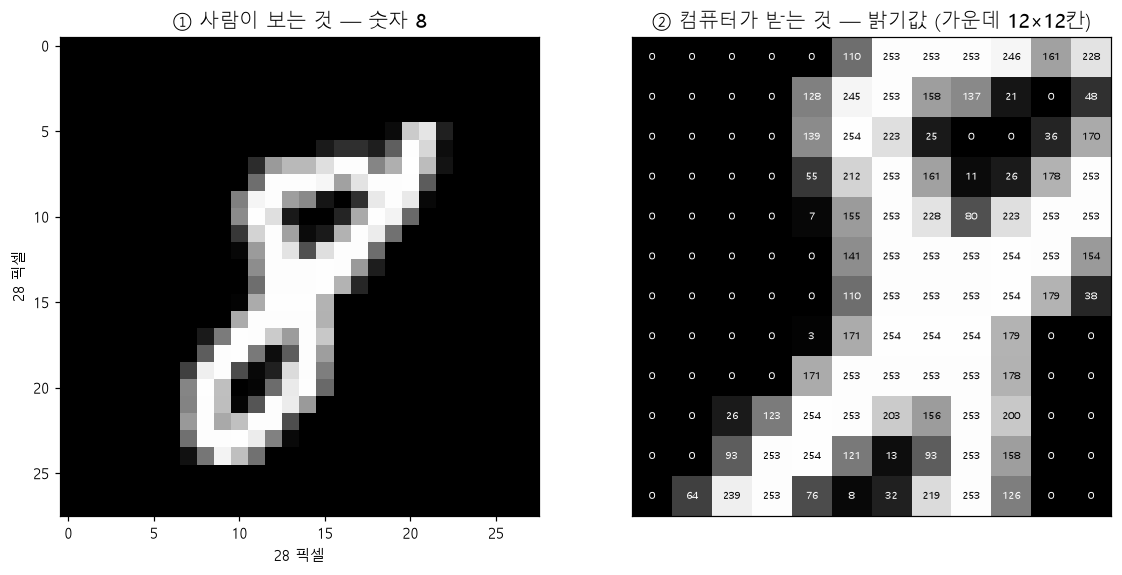

In [3]:
# ============================================================
# [결과 보기용 보조 코드 — CNN 핵심 코드가 아닙니다]
#
# 숫자 8 한 장을 골라 '사람이 보는 그림'과 '컴퓨터가 받는 밝기값'을
# 나란히 그려 줍니다. Python 문법을 한 줄씩 분석할 필요는 없습니다.
# 왼쪽과 오른쪽이 같은 이미지라는 점만 확인하세요.
# ============================================================
i = int(np.where(y_train == 8)[0][0])
img = x_train_raw[i]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"① 사람이 보는 것 — 숫자 {y_train[i]}", fontsize=13)
axes[0].set_xlabel("28 픽셀"); axes[0].set_ylabel("28 픽셀")

patch = img[8:20, 6:18]          # 784개를 다 쓰면 읽을 수 없어 가운데 일부만
axes[1].imshow(patch, cmap="gray", vmin=0, vmax=255)
for r in range(patch.shape[0]):
    for c in range(patch.shape[1]):
        v = int(patch[r, c])
        axes[1].text(c, r, str(v), ha="center", va="center",
                     fontsize=6.5, color="white" if v < 140 else "black")
axes[1].set_title("② 컴퓨터가 받는 것 — 밝기값 (가운데 12×12칸)", fontsize=13)
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()


## 02-2. 밝기값을 0 ~ 1 로 맞추기 (정규화)

밝기값을 그대로 넘기기 전에 **한 가지 정리**만 합니다.

<svg viewBox="0 0 980 250" role="img" aria-label="픽셀 밝기값을 0~255에서 0~1로 바꾸는 정규화" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:820px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>정규화 — 밝기값의 범위 맞추기</title><desc>원래 0~255 정수인 픽셀 밝기값을 255로 나누어 0~1 사이의 소수로 바꾸는 정규화 과정을 나타낸 그림.</desc><rect x="0" y="0" width="980" height="250" fill="#FFFFFF"/><text x="490" y="34" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">모델에 넣기 전, 밝기값의 범위만 맞춰 둡니다</text><rect x="140" y="66" width="250" height="116" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="265" y="96" font-size="13" fill="#4B5563" text-anchor="middle" font-weight="bold">원래 픽셀값</text><text x="265" y="136" font-size="26" fill="#3C4552" text-anchor="middle" font-weight="bold">0 ~ 255</text><text x="265" y="162" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal">정수</text><line x1="404" y1="124" x2="566" y2="124" stroke="#8A93A0" stroke-width="2.4"/><polygon points="576,124 566,118 566,130" fill="#8A93A0"/><text x="490" y="106" font-size="17" fill="#77400F" text-anchor="middle" font-weight="bold">÷ 255</text><text x="490" y="152" font-size="12" fill="#6B7280" text-anchor="middle" font-weight="normal">정규화</text><rect x="590" y="66" width="250" height="116" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="715" y="96" font-size="13" fill="#1B3A5E" text-anchor="middle" font-weight="bold">모델에 넣는 값</text><text x="715" y="136" font-size="26" fill="#1B3A5E" text-anchor="middle" font-weight="bold">0 ~ 1</text><text x="715" y="162" font-size="11.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal">소수</text><rect x="120" y="200" width="740" height="40" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="226" font-size="12.5" fill="#4B5563" text-anchor="middle" font-weight="normal">값의 크기가 너무 크면 학습이 불안정해질 수 있어 범위를 미리 맞춰 둡니다.</text></svg>

또 하나, `Conv2D` 는 `(높이, 너비, 채널)` 형태를 입력으로 받습니다.
MNIST는 흑백이라 채널이 1개이므로 `(28, 28)` → `(28, 28, 1)` 로 **모양만** 바꿉니다.
새로 계산하는 것은 없습니다.


In [4]:
# ① 정규화 : 0~255 → 0~1
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

# ② 채널 차원 추가 : (28, 28) → (28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("학습 이미지 :", x_train.shape, " 밝기값 범위 :", x_train.min(), "~", x_train.max())
print("테스트 이미지 :", x_test.shape, " 밝기값 범위 :", x_test.min(), "~", x_test.max())

학습 이미지 : (60000, 28, 28, 1)  밝기값 범위 : 0.0 ~ 1.0
테스트 이미지 : (10000, 28, 28, 1)  밝기값 범위 : 0.0 ~ 1.0


---
# 03. CNN을 코드로 만들기

## 03-1. 그림의 `Conv → ReLU` 는 코드에서 한 줄

전체 지도(00-1)에서는 Conv 뒤에 ReLU가 따라옵니다.
그런데 코드를 보면 `ReLU` 라는 이름의 층이 보이지 않습니다. 왜 그럴까요?

<svg viewBox="0 0 980 510" role="img" aria-label="개념 그림의 Conv와 ReLU가 실제 코드에서는 한 줄인 이유" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>그림의 Conv → ReLU 는 코드에서 한 줄</title><desc>개념 그림에서는 Conv와 ReLU를 두 단계로 나누어 그리지만 실제 TensorFlow 코드에서는 Conv2D 층의 activation=relu 인자로 함께 작성된다는 점을 좌우로 비교한 그림.</desc><rect x="0" y="0" width="980" height="510" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">그림의 Conv → ReLU 는 코드에서 한 줄입니다</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">같은 동작을 그림은 2단계로, 코드는 1줄로 표현합니다</text><rect x="50" y="78" width="380" height="330" rx="12" ry="12" fill="#FBFAFD" stroke="#7B5EA7" stroke-width="1.5" stroke-dasharray="6 5"/><text x="240" y="106" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">개념 그림에서는 2단계</text><rect x="130" y="122" width="220" height="56" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="240" y="146" font-size="16" fill="#3B295D" text-anchor="middle" font-weight="bold">Conv</text><text x="240" y="166" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.8">3×3 필터로 곱하고 더하기</text><line x1="240" y1="178" x2="240" y2="198" stroke="#8A93A0" stroke-width="2"/><polygon points="240,208 234,198 246,198" fill="#8A93A0"/><rect x="130" y="208" width="220" height="66" rx="10" ry="10" fill="#F6F3FB" stroke="#7B5EA7" stroke-width="1.5"/><text x="240" y="232" font-size="16" fill="#3B295D" text-anchor="middle" font-weight="bold">ReLU</text><text x="240" y="252" font-size="11" fill="#7A2E12" text-anchor="middle" font-weight="normal">음수 → 0</text><text x="240" y="268" font-size="11" fill="#0E4A46" text-anchor="middle" font-weight="normal">양수 → 그대로</text><line x1="240" y1="274" x2="240" y2="294" stroke="#8A93A0" stroke-width="2"/><polygon points="240,304 234,294 246,294" fill="#8A93A0"/><rect x="130" y="304" width="220" height="62" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="240" y="330" font-size="15" fill="#0E4A46" text-anchor="middle" font-weight="bold">Feature Map</text><text x="240" y="352" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.8">다음 단계로 전달</text><text x="240" y="390" font-size="11" fill="#6B7280" text-anchor="middle" font-weight="normal">우리가 화면에서 확인하는 결과</text><text x="490" y="236" font-size="34" fill="#6B7280" text-anchor="middle" font-weight="bold">=</text><text x="490" y="274" font-size="14" fill="#3C4552" text-anchor="middle" font-weight="bold">같은 의미</text><rect x="550" y="78" width="380" height="330" rx="12" ry="12" fill="#FFFDF9" stroke="#DE8A3E" stroke-width="1.5" stroke-dasharray="6 5"/><text x="740" y="106" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">실제 TensorFlow 코드에서는 한 줄</text><rect x="578" y="122" width="324" height="176" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="598" y="152" font-size="12.5" fill="#3C4552" text-anchor="start" font-weight="normal" font-family="Consolas,'Courier New','D2Coding',monospace" xml:space="preserve">tf.keras.layers.Conv2D(</text><text x="598" y="180" font-size="12.5" fill="#3C4552" text-anchor="start" font-weight="normal" font-family="Consolas,'Courier New','D2Coding',monospace" xml:space="preserve">    8,</text><text x="598" y="208" font-size="12.5" fill="#3C4552" text-anchor="start" font-weight="normal" font-family="Consolas,'Courier New','D2Coding',monospace" xml:space="preserve">    kernel_size=3,</text><text x="598" y="236" font-size="12.5" fill="#77400F" text-anchor="start" font-weight="bold" font-family="Consolas,'Courier New','D2Coding',monospace" xml:space="preserve">    activation="relu"</text><text x="598" y="264" font-size="12.5" fill="#3C4552" text-anchor="start" font-weight="normal" font-family="Consolas,'Courier New','D2Coding',monospace" xml:space="preserve">)</text><text x="806" y="236" font-size="12" fill="#77400F" text-anchor="start" font-weight="bold">← ReLU</text><text x="740" y="330" font-size="12.5" fill="#77400F" text-anchor="middle" font-weight="normal">Conv2D 층 안에 ReLU가 함께 들어 있습니다.</text><text x="740" y="356" font-size="12.5" fill="#77400F" text-anchor="middle" font-weight="normal">그래서 코드에는 ReLU 층이</text><text x="740" y="378" font-size="12.5" fill="#77400F" text-anchor="middle" font-weight="normal">따로 보이지 않습니다.</text><rect x="60" y="426" width="860" height="66" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="454" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">이 노트북에서 말하는 Feature Map = Conv2D(..., activation="relu") 의 출력</text><text x="490" y="478" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">즉 Conv 계산과 ReLU 를 모두 지난 결과를 화면에서 확인합니다.</text></svg>

> 그림에서는 CNN의 동작을 이해하기 쉽도록 `Conv → ReLU` 를 **두 단계로 나누어** 표시합니다.
> 실제 TensorFlow 코드에서는 `activation="relu"` 로 **Conv2D 층 안에 함께** 작성했습니다.

"그림에는 ReLU가 있는데 코드에는 없네?" 라고 생각하지 않아도 됩니다.


## 03-2. 코드 속 숫자와 이름의 의미

먼저 `Conv2D` 부터 봅니다.

`Conv2D(8, kernel_size=3, activation="relu")`

| 코드 | 쉬운 의미 |
|---|---|
| `8` | 서로 다른 **필터 8개** |
| `kernel_size=3` | 필터 한 개의 크기 **3 × 3** |
| `Conv2D` | 필터가 이미지 위를 **이동하며 계산** |
| `activation="relu"` | Conv 결과의 **음수를 0으로** 처리 |
| 결과 | **Feature Map 8장** |

> **필터 8개 → 서로 다른 Feature Map 8장**

나머지 층도 같은 방식으로 읽습니다.

| 코드 | 쉬운 의미 |
|---|---|
| `MaxPooling2D(2)` | 2 × 2 영역에서 큰 값을 남기며 **크기 축소** |
| `Flatten()` | 여러 Feature Map을 **한 줄의 숫자로 펼침** |
| `Dense(10)` | 숫자 0~9에 대응하는 **10개 출력** 생성 |
| `activation="softmax"` | 10개 후보를 **비교하기 쉬운 점수**로 변환 |

### 코드를 위에서 아래로 읽으면 그대로 흐름입니다

아래 코드는 `Sequential` 구조입니다.
`Sequential` 은 **앞 단계의 출력이 그대로 다음 단계의 입력이 되는** 구조를 뜻합니다.

| 단계 | 코드 | 출력 크기 | 하는 일 |
|---|---|---|---|
| ① | `Input(shape=(28, 28, 1))` | `(28, 28, 1)` | 숫자 이미지 한 장 |
| ② | `Conv2D(8, 3, "relu")` | `(26, 26, 8)` | 작은 특징 찾기 + ReLU |
| ③ | `MaxPooling2D(2)` | `(13, 13, 8)` | 크기 절반으로 축소 |
| ④ | `Conv2D(16, 3, "relu")` | `(11, 11, 16)` | 앞 특징을 조합 |
| ⑤ | `MaxPooling2D(2)` | `(5, 5, 16)` | 크기 절반으로 축소 |
| ⑥ | `Flatten()` | `(400,)` | 한 줄로 펼치기 |
| ⑦ | `Dense(10, "softmax")` | `(10,)` | ⑧ 0~9 후보 점수 |


In [5]:
# ============================================================
# ★ CNN 본체 — tf.keras.Sequential
#
# Sequential = 앞 단계의 출력이 그대로 다음 단계의 입력이 되는 구조
# 아래 코드를 위에서 아래로 읽으면 03장 그림의 ① → ⑦ 순서와 같습니다.
# ============================================================
model = tf.keras.Sequential([

    # ───────────────────────────────────────
    # ① 입력 — 숫자 이미지 한 장
    #
    # 무엇이 들어오나요 : 0~1 로 맞춘 28×28 밝기값, 흑백 1장
    # 무엇이 나가나요   : (28, 28, 1)
    # 다음 단계         : ② Conv2D
    # ───────────────────────────────────────
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # ───────────────────────────────────────
    # ② Conv2D + ReLU — 작은 특징 찾기
    #
    # 무엇이 들어오나요 : 28×28 밝기값 1장
    # 무엇을 하나요     : 3×3 필터 8개가 이미지 위를 한 칸씩 이동하면서
    #                     같은 위치끼리 곱하고, 9개 값을 모두 더합니다.
    #                     그 결과 한 개가 Feature Map의 한 칸이 됩니다.
    # 왜 필요한가요     : 숫자의 의미는 픽셀 하나가 아니라
    #                     여러 픽셀이 이루는 '모양'에 들어 있기 때문입니다.
    # 무엇이 나가나요   : 26×26 크기의 Feature Map 8장  (필터 8개 → 8장)
    # 다음 단계         : ③ MaxPooling 으로 넘어갑니다.
    #
    # ReLU:
    # Conv 결과의 음수는 0으로 만들고, 양수 반응은 그대로 넘깁니다.
    # 그림에서는 Conv → ReLU 를 두 단계로 나누어 그리지만,
    # 코드에서는 activation="relu" 로 Conv2D 안에 함께 들어 있습니다.
    # 이 노트북에서는 이 층의 출력을 Feature Map이라고 부릅니다.
    # ───────────────────────────────────────
    tf.keras.layers.Conv2D(8, kernel_size=3, activation="relu", name="conv1"),

    # ───────────────────────────────────────
    # ③ MaxPooling — 강한 반응만 남기고 크기 줄이기
    #
    # 무엇이 들어오나요 : 26×26 Feature Map 8장
    # 무엇을 하나요     : 2×2 영역마다 가장 큰 값 하나만 남깁니다.
    # 왜 필요한가요     : 강한 반응을 남기면서 다음 계산을 가볍게 합니다.
    # 무엇이 나가나요   : 13×13 Feature Map 8장 (장수는 그대로)
    # 다음 단계         : ④ 두 번째 Conv2D
    # ───────────────────────────────────────
    tf.keras.layers.MaxPooling2D(2, name="pool1"),

    # ───────────────────────────────────────
    # ④ 두 번째 Conv2D + ReLU — 앞 특징을 다시 조합
    #
    # 무엇이 들어오나요 : 원본 이미지가 아니라,
    #                     ②~③ 에서 만들어진 Feature Map 8장(13×13×8)입니다.
    # 무엇을 하나요     : 8장을 함께 보면서 여러 특징이 겹치는
    #                     더 복합적인 모양을 찾습니다.
    # 왜 필요한가요     : 작은 선·모서리만으로는 숫자를 구분하기 어렵고,
    #                     그것들이 조합된 형태가 필요하기 때문입니다.
    # 무엇이 나가나요   : 11×11 Feature Map 16장
    # 다음 단계         : ⑤ MaxPooling
    # ───────────────────────────────────────
    tf.keras.layers.Conv2D(16, kernel_size=3, activation="relu", name="conv2"),

    # ───────────────────────────────────────
    # ⑤ 두 번째 MaxPooling
    #
    # 11×11 Feature Map 16장 → 5×5 Feature Map 16장
    # ───────────────────────────────────────
    tf.keras.layers.MaxPooling2D(2, name="pool2"),

    # ───────────────────────────────────────
    # ⑥ Flatten — 한 줄로 펼치기
    #
    # 무엇이 들어오나요 : 5×5 Feature Map 16장
    # 무엇을 하나요     : 격자 모양을 순서대로 이어 붙여 한 줄로 만듭니다.
    #                     새로 계산하는 것은 없고 '모양만' 바꿉니다.
    # 왜 필요한가요     : Dense 출력층은 격자가 아니라
    #                     한 줄로 늘어선 값을 입력으로 받기 때문입니다.
    # 무엇이 나가나요   : 5 × 5 × 16 = 400개 숫자 한 줄
    # 다음 단계         : ⑦ Dense
    # ───────────────────────────────────────
    tf.keras.layers.Flatten(name="flatten"),

    # ───────────────────────────────────────
    # ⑦ Dense + Softmax — 0~9 후보 점수 만들기
    #
    # 무엇이 들어오나요 : 400개 숫자 한 줄
    # 무엇을 하나요     : 0~9 각각에 대한 점수를 계산합니다.
    #                     softmax는 10개 점수의 합이 1이 되도록 맞춰,
    #                     서로 비교하기 쉬운 형태로 만들어 줍니다.
    # 왜 10개인가요     : 우리가 고르려는 후보가 0,1,2,...,9 로 10개이기 때문입니다.
    # 무엇이 나가나요   : ⑧ 0~9 후보 점수 10개
    # ───────────────────────────────────────
    tf.keras.layers.Dense(10, activation="softmax", name="output_10"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_10 (Dense)               │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,258 (20.54 KB)

 Trainable params: 5,258 (20.54 KB)

 Non-trainable params: 0 (0.00 B)

## 03-3. `summary()` 출력을 흐름으로 읽으면

| 단계 | 층 이름 | 출력 모양 | 학습되는 값 |
|---|---|---|---|
| ① | 입력 | `(28, 28, 1)` | 없음 |
| ② | `conv1` | `(26, 26, 8)` | **필터 값** |
| ③ | `pool1` | `(13, 13, 8)` | 없음 |
| ④ | `conv2` | `(11, 11, 16)` | **필터 값** |
| ⑤ | `pool2` | `(5, 5, 16)` | 없음 |
| ⑥ | `flatten` | `(400,)` | 없음 |
| ⑦ | `output_10` | `(10,)` | **Weight / Bias** |

> 출력 모양 맨 앞의 `None` 은 "한 번에 처리하는 이미지 장수"이며, 아직 정해지지 않았다는 뜻입니다.

지금 이 필터 값과 Weight는 **아직 학습되지 않은 무작위 값**입니다.
어떤 값이 어떻게 바뀌는지는 05장에서 봅니다.


---
# 04. ★ Conv2D는 어떻게 특징을 찾나?

> ① 이미지  →  **② Conv + ReLU ← 현재**  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

## 04-1. Conv 한 칸은 어떻게 계산할까?

**이번 실습에서 가장 중요한 부분입니다.**

지금 들어오는 것은 28 × 28 개의 밝기값(0~1)입니다.
Conv는 이 전체를 한 번에 보지 않고, **작은 3 × 3 영역 하나씩** 봅니다.

<svg viewBox="0 0 980 580" role="img" aria-label="Conv 한 칸이 계산되는 과정" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>Conv 한 칸은 어떻게 계산되나?</title><desc>이미지의 3×3 영역과 3×3 필터를 같은 위치끼리 곱한 뒤 9개 값을 모두 더해 Feature Map 한 칸을 만드는 과정을 좌우 2열로 나타낸 그림.</desc><rect x="0" y="0" width="980" height="580" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">Conv 한 칸은 어떻게 계산되나?</text><rect x="40" y="52" width="900" height="32" rx="8" ry="8" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="490" y="73" font-size="12" fill="#77400F" text-anchor="middle" font-weight="normal">⚠ 아래 숫자는 계산 방법을 보여 주기 위한 설명용 예시이며, 실제 학습된 필터 값이 아닙니다</text><text x="171" y="128" font-size="12.5" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 이미지의 3 × 3 부분</text><rect x="102" y="142" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="125.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="148" y="142" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="171.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="194" y="142" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="217.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="102" y="188" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="125.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="148" y="188" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="171.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="194" y="188" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="217.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="102" y="234" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="125.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="148" y="234" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="171.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="194" y="234" width="46" height="46" fill="#E8F0FB" stroke="#8A93A0" stroke-width="1.2"/><text x="217.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><text x="309" y="214" font-size="26" fill="#6B7280" text-anchor="middle" font-weight="normal">×</text><text x="409" y="128" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="bold">② 3 × 3 필터 (설명용 예시)</text><rect x="340" y="142" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="363.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="386" y="142" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="409.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="432" y="142" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="455.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">−1</text><rect x="340" y="188" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="363.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="386" y="188" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="409.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="432" y="188" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="455.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">−1</text><rect x="340" y="234" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="363.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="386" y="234" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="409.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="432" y="234" width="46" height="46" fill="#EEE9F7" stroke="#8A93A0" stroke-width="1.2"/><text x="455.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">−1</text><line x1="492" y1="211" x2="622" y2="211" stroke="#8A93A0" stroke-width="2.4"/><polygon points="632,211 622,205 622,217" fill="#8A93A0"/><text x="562" y="194" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">같은 자리끼리</text><text x="730" y="128" font-size="12.5" fill="#3C4552" text-anchor="middle" font-weight="bold">③ 같은 위치끼리 곱한 결과</text><rect x="661" y="142" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="684.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="707" y="142" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="730.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="753" y="142" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="776.0" y="170.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">−1</text><rect x="661" y="188" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="684.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="707" y="188" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="730.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="753" y="188" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="776.0" y="216.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="661" y="234" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="684.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="707" y="234" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="730.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><rect x="753" y="234" width="46" height="46" fill="#FFFFFF" stroke="#8A93A0" stroke-width="1.2"/><text x="776.0" y="262.4" font-size="15" fill="#1F2733" text-anchor="middle" font-weight="bold">0</text><line x1="730" y1="288" x2="730" y2="312" stroke="#8A93A0" stroke-width="2"/><polygon points="730,322 724,312 736,312" fill="#8A93A0"/><rect x="550" y="322" width="360" height="84" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="730" y="350" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">④ 9개 값을 모두 더하기</text><text x="730" y="382" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="normal">1 + 0 + (−1) + 0 + 0 + 0 + 1 + 0 + 0  =  1</text><line x1="730" y1="406" x2="730" y2="430" stroke="#8A93A0" stroke-width="2"/><polygon points="730,440 724,430 736,430" fill="#8A93A0"/><rect x="596" y="440" width="268" height="76" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="694" y="488" font-size="13" fill="#0E4A46" text-anchor="middle" font-weight="bold">⑤ Feature Map 한 칸  =</text><rect x="808" y="456" width="44" height="44" fill="#FFFFFF" stroke="#2E9E96" stroke-width="1.6"/><text x="830" y="486" font-size="17" fill="#0E4A46" text-anchor="middle" font-weight="bold">1</text><rect x="60" y="322" width="440" height="194" rx="12" ry="12" fill="#FBFAFD" stroke="#7B5EA7" stroke-width="1.5" stroke-dasharray="6 5"/><text x="280" y="354" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">이 계산이 하는 일</text><text x="280" y="386" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">이미지의 작은 3 × 3 영역과 필터를</text><text x="280" y="410" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">같은 자리끼리 곱해서 모두 더합니다.</text><text x="280" y="446" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">결과 값이 클수록 그 위치에서</text><text x="280" y="470" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">필터가 강하게 반응했다는 뜻입니다.</text><text x="280" y="500" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">※ 필터 = 어떤 패턴에 얼마나 반응하는지 계산하는 작은 숫자 묶음</text><rect x="60" y="532" width="860" height="36" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="556" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="bold">여기까지가 Feature Map 「한 칸」입니다. 다음은 필터를 이동시킵니다.</text></svg>

> 여기서 나온 값 **하나**가 Feature Map의 **한 칸**입니다.
> 값이 클수록 그 위치에서 필터가 강하게 반응했다는 뜻입니다.


## 04-2. 한 칸에서 Feature Map 한 장으로

필터는 이미지 위를 **한 칸씩 이동**하면서 04-1의 계산을 반복합니다.
그래서 이미지 전체를 훑고 나면 **Feature Map 한 장**이 완성됩니다.

<svg viewBox="0 0 980 470" role="img" aria-label="필터가 이동하며 Feature Map 한 장이 완성되는 과정" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>필터를 한 칸씩 이동하면 Feature Map 한 장이 됩니다</title><desc>3×3 필터가 이미지 위를 한 칸씩 이동하면서 위치마다 같은 계산을 반복해 Feature Map 한 장이 채워지는 과정을 나타낸 그림.</desc><rect x="0" y="0" width="980" height="470" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">필터를 한 칸씩 이동하면 Feature Map 한 장이 됩니다</text><text x="490" y="58" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">설명용 예시 : 6 × 6 이미지 · 3 × 3 필터</text><rect x="120" y="90" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="154" y="90" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="188" y="90" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="222" y="90" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="256" y="90" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="290" y="90" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="120" y="124" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="154" y="124" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="188" y="124" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="222" y="124" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="256" y="124" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="290" y="124" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="120" y="158" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="154" y="158" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="188" y="158" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="222" y="158" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="256" y="158" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="290" y="158" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="120" y="192" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="154" y="192" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="188" y="192" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="222" y="192" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="256" y="192" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="290" y="192" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="120" y="226" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="154" y="226" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="188" y="226" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="222" y="226" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="256" y="226" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="290" y="226" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="120" y="260" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="154" y="260" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="188" y="260" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="222" y="260" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="256" y="260" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="290" y="260" width="34" height="34" fill="#F7F9FC" stroke="#CBD0D8" stroke-width="1.2"/><rect x="120" y="90" width="102" height="102" fill="none" stroke="#DE8A3E" stroke-width="3"/><rect x="154" y="90" width="102" height="102" fill="none" stroke="#DE8A3E" stroke-width="2" stroke-dasharray="6 4"/><text x="222" y="324" font-size="13" fill="#1B3A5E" text-anchor="middle" font-weight="bold">이미지 (6 × 6)</text><text x="222" y="346" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">실선 = 첫 번째 위치 · 점선 = 오른쪽으로 한 칸</text><line x1="360" y1="192" x2="596" y2="192" stroke="#8A93A0" stroke-width="2.4"/><polygon points="606,192 596,186 596,198" fill="#8A93A0"/><text x="483" y="172" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">위치마다 곱하고 더하기</text><text x="483" y="216" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">오른쪽 끝까지 가면 한 줄 아래로</text><rect x="640" y="124" width="34" height="34" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.2"/><text x="657.0" y="146.04" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">1</text><rect x="674" y="124" width="34" height="34" fill="#FDF6EC" stroke="#DE8A3E" stroke-width="1.2"/><rect x="708" y="124" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="742" y="124" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="640" y="158" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="674" y="158" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="708" y="158" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="742" y="158" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="640" y="192" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="674" y="192" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="708" y="192" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="742" y="192" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="640" y="226" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="674" y="226" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="708" y="226" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><rect x="742" y="226" width="34" height="34" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.2"/><text x="708" y="324" font-size="13" fill="#77400F" text-anchor="middle" font-weight="bold">Feature Map (4 × 4)</text><text x="708" y="346" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">첫 칸 = 1 · 다음 칸 = 이동한 위치의 계산 결과</text><rect x="70" y="376" width="840" height="76" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="406" font-size="14" fill="#3C4552" text-anchor="middle" font-weight="bold">실제 실습에서는 28 × 28 이미지를 3 × 3 필터로 훑어 26 × 26 Feature Map 한 장이 완성됩니다.</text><text x="490" y="432" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">가장자리는 3 × 3 영역을 만들 수 없어 가로 · 세로가 2칸씩 줄어듭니다.  (28 − 3 + 1 = 26)</text></svg>

> **Feature Map** = 필터가 이미지의 어느 위치에서 얼마나 강하게 반응했는지를
> 위치별 숫자로 모아 놓은 결과입니다.

필터 안의 숫자는 사람이 "세로선 필터", "곡선 필터" 라고 미리 정해 준 것이 아닙니다.
처음에는 무작위 값으로 시작하고, **학습 과정에서 Loss를 줄이는 방향으로 바뀝니다.**


## 04-3. ReLU와 다음 단계

Conv가 만든 모든 반응을 그대로 쓰는 것이 아니라, **ReLU를 한 번 거쳐** 다음 단계로 넘깁니다.

<svg viewBox="0 0 980 310" role="img" aria-label="ReLU가 음수를 0으로 바꾸고 양수를 그대로 전달하는 과정" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:880px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>ReLU — 음수는 0으로, 양수는 그대로</title><desc>Conv 계산 결과 중 음수 값은 0으로 바뀌고 양수 값은 그대로 전달되어 모든 값이 0 이상인 Feature Map이 되는 과정을 나타낸 그림.</desc><rect x="0" y="0" width="980" height="310" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">ReLU — 음수는 0으로, 양수는 그대로</text><rect x="50" y="92" width="210" height="92" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="155" y="128" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">Conv 계산 결과</text><text x="155" y="154" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">음수와 양수가</text><text x="155" y="172" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">섞여 있습니다</text><line x1="266" y1="130" x2="307.9" y2="109.9" stroke="#8A93A0" stroke-width="1.8"/><polygon points="316,106 309.5,113.3 306.3,106.5" fill="#8A93A0"/><line x1="266" y1="150" x2="308.1" y2="173.6" stroke="#8A93A0" stroke-width="1.8"/><polygon points="316,178 306.3,176.9 310.0,170.3" fill="#8A93A0"/><rect x="322" y="78" width="240" height="60" rx="10" ry="10" fill="#FBEEEA" stroke="#C4633F" stroke-width="1.5"/><text x="442" y="102" font-size="13" fill="#7A2E12" text-anchor="middle" font-weight="bold">음수 값</text><text x="442" y="124" font-size="12.5" fill="#7A2E12" text-anchor="middle" font-weight="normal">→  0 으로 바꿈</text><rect x="322" y="150" width="240" height="60" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="442" y="174" font-size="13" fill="#0E4A46" text-anchor="middle" font-weight="bold">양수 값</text><text x="442" y="196" font-size="12.5" fill="#0E4A46" text-anchor="middle" font-weight="normal">→  그대로 전달</text><line x1="566" y1="108" x2="607.8" y2="126.4" stroke="#8A93A0" stroke-width="1.8"/><polygon points="616,130 606.2,129.8 609.3,122.9" fill="#8A93A0"/><line x1="566" y1="180" x2="608.1" y2="156.4" stroke="#8A93A0" stroke-width="1.8"/><polygon points="616,152 610.0,159.7 606.3,153.1" fill="#8A93A0"/><rect x="622" y="92" width="300" height="92" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="772" y="128" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">ReLU를 지난 Feature Map</text><text x="772" y="156" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">모든 값이 0 이상입니다</text><rect x="70" y="226" width="840" height="66" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="254" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">코드에서는 activation="relu" 한 줄이 이 일을 합니다.</text><text x="490" y="278" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">이 결과가 그대로 다음 단계인 MaxPooling 으로 넘어갑니다.</text></svg>

### 무엇이 출력되나요?
**26 × 26 크기의 Feature Map**이며, 모든 값이 0 이상입니다.
필터가 8개이므로 **8장**이 만들어집니다. (자세한 그림은 06장에서 봅니다.)

### 다음 단계에는 무엇이 넘어가나요?
이 8장이 그대로 `MaxPooling2D` 로 넘어갑니다.

> ① 이미지  →  **② Conv + ReLU ← 지금까지 확대해서 봄**  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

> 그런데 지금 필터 값은 아직 무작위입니다.
> 그래서 **먼저 학습을 한 뒤**(05장) 실제 Feature Map을 확인합니다(06장).


---
# 05. ★ CNN은 어떻게 학습하나?

## 05-1. 학습 한 바퀴는 어떻게 도나?

지금 모델의 필터값과 Weight는 **아직 학습되지 않은 무작위 값**입니다.
학습 전에도 Feature Map은 만들어지지만, 아직 **숫자를 구분하는 목적에 맞게 조정된 특징이라고 보기는 어렵습니다.**

<svg viewBox="0 0 980 700" role="img" aria-label="CNN 학습이 반복되는 한 바퀴" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>CNN 학습이 반복되는 한 바퀴</title><desc>이미지가 CNN Forward를 지나 0~9 후보 점수가 되고, 정답과 비교해 Loss를 계산한 뒤 역전파와 Optimizer를 거쳐 Conv 필터와 Dense Weight/Bias가 수정되고 다시 Forward로 돌아오는 학습 반복 과정을 나타낸 순환 흐름도.</desc><rect x="0" y="0" width="980" height="700" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">CNN은 어떻게 학습하나 — 반복되는 한 바퀴</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">model.fit() 한 줄 안에서 아래 과정이 계속 반복됩니다</text><rect x="70" y="86" width="190" height="92" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="165" y="124" font-size="14" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 이미지 한 묶음</text><text x="165" y="150" font-size="11.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.85">x_train (128장씩)</text><line x1="264" y1="132" x2="296" y2="132" stroke="#8A93A0" stroke-width="2"/><polygon points="306,132 296,126 296,138" fill="#8A93A0"/><rect x="306" y="86" width="354" height="92" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="483" y="118" font-size="15" fill="#3B295D" text-anchor="middle" font-weight="bold">② CNN Forward</text><text x="483" y="144" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">Conv → Pool → Conv → Pool</text><text x="483" y="166" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">→ Flatten → Dense + Softmax</text><line x1="664" y1="132" x2="696" y2="132" stroke="#8A93A0" stroke-width="2"/><polygon points="706,132 696,126 696,138" fill="#8A93A0"/><rect x="706" y="86" width="204" height="92" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="808" y="124" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">③ 0~9 후보 점수</text><text x="808" y="150" font-size="11.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.85">10개의 점수</text><line x1="808" y1="178" x2="808" y2="212" stroke="#8A93A0" stroke-width="2"/><polygon points="808,222 802,212 814,212" fill="#8A93A0"/><rect x="706" y="222" width="204" height="76" rx="10" ry="10" fill="#FFFFFF" stroke="#CBD0D8" stroke-width="1.5"/><text x="808" y="252" font-size="14" fill="#4B5563" text-anchor="middle" font-weight="bold">④ 정답과 비교</text><text x="808" y="276" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.85">y_train (실제 숫자)</text><line x1="808" y1="298" x2="808" y2="332" stroke="#8A93A0" stroke-width="2"/><polygon points="808,342 802,332 814,332" fill="#8A93A0"/><rect x="706" y="342" width="204" height="76" rx="10" ry="10" fill="#FBEEEA" stroke="#C4633F" stroke-width="1.5"/><text x="808" y="372" font-size="15" fill="#7A2E12" text-anchor="middle" font-weight="bold">⑤ Loss</text><text x="808" y="396" font-size="11.5" fill="#7A2E12" text-anchor="middle" font-weight="normal">틀린 정도를 숫자 하나로</text><line x1="808" y1="418" x2="808" y2="452" stroke="#8A93A0" stroke-width="2"/><polygon points="808,462 802,452 814,452" fill="#8A93A0"/><rect x="706" y="462" width="204" height="92" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="808" y="492" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">⑥ 역전파</text><text x="808" y="516" font-size="11" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">Backpropagation</text><text x="808" y="538" font-size="11" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">어느 값을 어느 쪽으로</text><line x1="702" y1="508" x2="674" y2="508" stroke="#8A93A0" stroke-width="2"/><polygon points="664,508 674,502 674,514" fill="#8A93A0"/><rect x="430" y="462" width="230" height="92" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="545" y="498" font-size="14" fill="#0E4A46" text-anchor="middle" font-weight="bold">⑦ Optimizer</text><text x="545" y="524" font-size="11.5" fill="#0E4A46" text-anchor="middle" font-weight="normal">실제로 값을 조금씩 수정</text><line x1="426" y1="508" x2="398" y2="508" stroke="#8A93A0" stroke-width="2"/><polygon points="388,508 398,502 398,514" fill="#8A93A0"/><rect x="90" y="462" width="294" height="92" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="237" y="492" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="bold">⑧ Conv Filter  +</text><text x="237" y="516" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="bold">Dense Weight / Bias 수정</text><text x="237" y="540" font-size="11" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.8">학습으로 바뀌는 값은 이 두 가지뿐</text><path d="M 90 508 L 42 508 L 42 132 L 58 132" fill="none" stroke="#8A93A0" stroke-width="2"/><polygon points="68,132 58,126 58,138" fill="#8A93A0"/><text x="96" y="582" font-size="11.5" fill="#6B7280" text-anchor="start" font-weight="normal">수정된 값으로 다시 Forward (반복)</text><rect x="150" y="232" width="480" height="170" rx="12" ry="12" fill="#FFFDF9" stroke="#DE8A3E" stroke-width="2"/><text x="390" y="268" font-size="16" fill="#77400F" text-anchor="middle" font-weight="bold">★ 여기가 가장 중요합니다</text><text x="390" y="304" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="normal">Optimizer가 Conv 필터 값을 바꾸면</text><text x="390" y="330" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="normal">다음 Forward에서 만들어지는 Feature Map도 달라지고</text><text x="390" y="356" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="normal">그 결과 0~9 후보 점수도 함께 달라집니다.</text><text x="390" y="386" font-size="12" fill="#6B7280" text-anchor="middle" font-weight="normal">학습은 같은 CNN을 조금씩 고쳐 가는 과정입니다.</text><rect x="70" y="606" width="840" height="64" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="632" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="bold">학습되는 값 :  Conv2D 필터  ·  Dense Weight / Bias</text><text x="490" y="656" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">학습할 값이 없는 단계 :  ReLU · MaxPooling · Flatten  (값을 고르거나 모양만 바꿉니다)</text></svg>

### ★ 이 그림에서 가장 중요한 연결

> **Optimizer가 Conv 필터를 바꾸면, 다음 Forward에서 만들어지는 Feature Map도 달라집니다.**

즉 학습은 예측과 별개의 이야기가 아니라, **같은 CNN을 조금씩 고쳐 가는 과정**입니다.
(이 연결은 마지막 08-3에서 한 번 더 정리합니다.)


## 05-2. 실제로 어떤 값이 바뀌나?

CNN의 모든 단계가 학습되는 것은 아닙니다.

| 단계 | 학습되는 내부 값 | 하는 일 |
|---|---|---|
| `Conv2D` | **필터 값이 학습됨** | 3×3 필터로 곱하고 더하기 |
| `ReLU` | 학습할 값 없음 | 음수를 0으로 바꿀 뿐 |
| `MaxPooling` | 학습할 값 없음 | 가장 큰 값을 고를 뿐 |
| `Flatten` | 학습할 값 없음 | 모양만 바꿀 뿐 |
| `Dense` | **Weight / Bias가 학습됨** | 0~9 후보 점수 계산 |

> 그래서 "CNN이 학습한다"는 말은 사실상
> **Conv 필터 값과 Dense Weight/Bias 값이 조금씩 수정된다**는 뜻입니다.

### 외울 필요가 없는 것

- `optimizer="adam"` 의 세부 문법
- `loss="sparse_categorical_crossentropy"` 라는 이름
- `batch_size` 같은 옵션

### 꼭 기억할 것

> `model.fit()` 안에서 **예측 → Loss → 역전파 → 값 수정** 이 반복되고,
> 그 결과 **Conv 필터가 바뀌어 Feature Map까지 달라진다.**

CPU 기준 30초 내외가 걸립니다.


In [6]:
# 학습 방법을 정합니다.
#   optimizer : 값을 어떤 방식으로 수정할지
#   loss      : 정답과 얼마나 다른지 재는 기준
#   metrics   : 사람이 보기 위한 참고 지표
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# ============================================================
# ★ CNN 학습 시작
#
# x_train → 숫자 이미지
# y_train → 각 이미지의 실제 정답 숫자
#
# model.fit() 내부에서는:
#
# ① Forward 로 0~9 후보 점수 계산
#    (Conv → Pool → Conv → Pool → Flatten → Dense + Softmax)
# ② 정답과 비교하여 Loss 계산
# ③ Backpropagation (역전파)
# ④ Optimizer 가 Conv Filter 와 Dense Weight/Bias 를 수정
# ⑤ 수정된 값으로 다시 Forward
#
# 이 과정을 반복합니다.
#
# 그래서 학습이 진행될수록 Conv 필터 값이 바뀌고,
# 다음 Forward 에서 만들어지는 Feature Map 도 함께 달라집니다.
# ============================================================
history = model.fit(
    x_train, y_train,       # 학습 이미지와 각 이미지의 실제 정답
    epochs=5,               # 학습 데이터 전체를 5번 반복해서 봅니다
    batch_size=128,         # 128장씩 처리하고 한 번씩 값을 수정합니다
    validation_split=0.1,   # 학습 데이터의 10%는 학습 중 확인용으로 사용합니다
    verbose=2,              # 진행 상황을 epoch 단위로만 출력합니다
)


Epoch 1/5


422/422 - 3s - 7ms/step - accuracy: 0.8550 - loss: 0.5204 - val_accuracy: 0.9642 - val_loss: 0.1316


Epoch 2/5


422/422 - 2s - 4ms/step - accuracy: 0.9595 - loss: 0.1350 - val_accuracy: 0.9723 - val_loss: 0.0901


Epoch 3/5


422/422 - 2s - 5ms/step - accuracy: 0.9701 - loss: 0.0982 - val_accuracy: 0.9770 - val_loss: 0.0737


Epoch 4/5


422/422 - 2s - 4ms/step - accuracy: 0.9750 - loss: 0.0811 - val_accuracy: 0.9800 - val_loss: 0.0653


Epoch 5/5


422/422 - 2s - 5ms/step - accuracy: 0.9781 - loss: 0.0706 - val_accuracy: 0.9817 - val_loss: 0.0605


### 결과를 보기 위한 보조 코드

아래 코드는 학습 결과를 그래프로 보기 위한 보조 코드입니다.
**Loss가 줄어드는지**와 **Accuracy가 올라가는지**만 확인하세요.


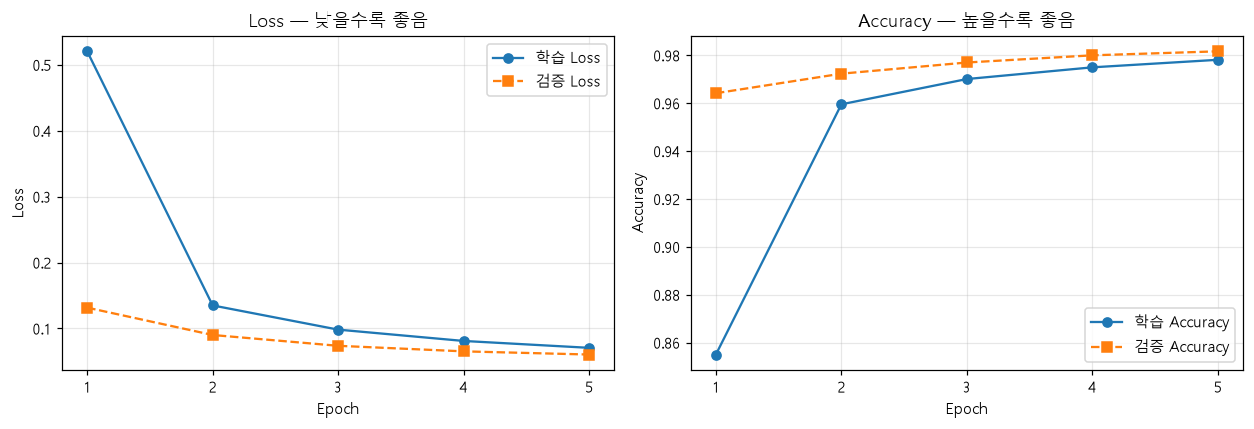

Loss     : 0.5204  →  0.0706   (줄어들었나요?)
Accuracy : 0.8550  →  0.9781   (올라갔나요?)

Conv 필터와 Dense Weight 값이 Loss를 줄이는 방향으로 수정된 결과입니다.


In [7]:
h = history.history
ep = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

axes[0].plot(ep, h["loss"], "o-", label="학습 Loss")
axes[0].plot(ep, h["val_loss"], "s--", label="검증 Loss")
axes[0].set_title("Loss — 낮을수록 좋음")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_xticks(list(ep)); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(ep, h["accuracy"], "o-", label="학습 Accuracy")
axes[1].plot(ep, h["val_accuracy"], "s--", label="검증 Accuracy")
axes[1].set_title("Accuracy — 높을수록 좋음")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_xticks(list(ep)); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Loss     : {h['loss'][0]:.4f}  →  {h['loss'][-1]:.4f}   (줄어들었나요?)")
print(f"Accuracy : {h['accuracy'][0]:.4f}  →  {h['accuracy'][-1]:.4f}   (올라갔나요?)")
print()
print("Conv 필터와 Dense Weight 값이 Loss를 줄이는 방향으로 수정된 결과입니다.")

---
# 06. ★ Feature Map과 Pooling

> ① 이미지  →  **② Conv + ReLU ← 현재 — 이 출력이 Feature Map**  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

## 06-1. 왜 필터 8개면 Feature Map도 8장인가?

<svg viewBox="0 0 980 640" role="img" aria-label="필터 8개가 Feature Map 8장을 만드는 과정" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>필터 8개가 Feature Map 8장을 만드는 과정</title><desc>같은 입력 이미지 한 장이 서로 다른 필터 8개를 각각 통과하여 26×26 크기의 Feature Map 8장이 되는 관계를 나타낸 그림.</desc><rect x="0" y="0" width="980" height="640" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">왜 필터 8개면 Feature Map도 8장인가?</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">같은 이미지 한 장이 서로 다른 필터 8개를 각각 통과합니다</text><rect x="60" y="74" width="860" height="32" rx="8" ry="8" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="490" y="95" font-size="12" fill="#77400F" text-anchor="middle" font-weight="normal">⚠ 개념 설명용 그림입니다. 각 필터가 무엇에 반응하는지는 학습 결과에 따라 정해집니다</text><rect x="50" y="256" width="170" height="120" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="135" y="298" font-size="14.5" fill="#1B3A5E" text-anchor="middle" font-weight="bold">입력 이미지 1장</text><text x="135" y="324" font-size="12.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal">28 × 28 × 1</text><text x="135" y="348" font-size="10.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.75">(8개 필터 모두 같은 이미지)</text><line x1="224" y1="316" x2="288.6" y2="156.3" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,148 292.1,157.8 285.1,154.9" fill="#8A93A0"/><rect x="300" y="130" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="153" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 1</text><line x1="384" y1="148" x2="454" y2="148" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,148 454,142 454,154" fill="#8A93A0"/><rect x="470" y="130" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="153" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 1  (26 × 26)</text><line x1="224" y1="316" x2="287.6" y2="203.8" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,196 290.9,205.7 284.3,202.0" fill="#8A93A0"/><rect x="300" y="178" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="201" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 2</text><line x1="384" y1="196" x2="454" y2="196" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,196 454,190 454,202" fill="#8A93A0"/><rect x="470" y="178" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="201" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 2  (26 × 26)</text><line x1="224" y1="316" x2="285.8" y2="250.5" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,244 288.6,253.1 283.1,247.9" fill="#8A93A0"/><rect x="300" y="226" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="249" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 3</text><line x1="384" y1="244" x2="454" y2="244" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,244 454,238 454,250" fill="#8A93A0"/><rect x="470" y="226" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="249" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 3  (26 × 26)</text><line x1="224" y1="316" x2="283.5" y2="295.0" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,292 284.8,298.6 282.3,291.4" fill="#8A93A0"/><rect x="300" y="274" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="297" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 4</text><line x1="384" y1="292" x2="454" y2="292" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,292 454,286 454,298" fill="#8A93A0"/><rect x="470" y="274" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="297" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 4  (26 × 26)</text><line x1="224" y1="316" x2="283.5" y2="337.0" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,340 282.3,340.6 284.8,333.4" fill="#8A93A0"/><rect x="300" y="322" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="345" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 5</text><line x1="384" y1="340" x2="454" y2="340" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,340 454,334 454,346" fill="#8A93A0"/><rect x="470" y="322" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="345" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 5  (26 × 26)</text><line x1="224" y1="316" x2="285.8" y2="381.5" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,388 283.1,384.1 288.6,378.9" fill="#8A93A0"/><rect x="300" y="370" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="393" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 6</text><line x1="384" y1="388" x2="454" y2="388" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,388 454,382 454,394" fill="#8A93A0"/><rect x="470" y="370" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="393" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 6  (26 × 26)</text><line x1="224" y1="316" x2="287.6" y2="428.2" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,436 284.3,430.0 290.9,426.3" fill="#8A93A0"/><rect x="300" y="418" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="441" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 7</text><line x1="384" y1="436" x2="454" y2="436" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,436 454,430 454,442" fill="#8A93A0"/><rect x="470" y="418" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="441" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 7  (26 × 26)</text><line x1="224" y1="316" x2="288.6" y2="475.7" stroke="#8A93A0" stroke-width="1.4"/><polygon points="292,484 285.1,477.1 292.1,474.2" fill="#8A93A0"/><rect x="300" y="466" width="76" height="36" rx="6" ry="6" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.4"/><text x="338" y="489" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="bold">필터 8</text><line x1="384" y1="484" x2="454" y2="484" stroke="#8A93A0" stroke-width="1.6"/><polygon points="464,484 454,478 454,490" fill="#8A93A0"/><rect x="470" y="466" width="210" height="36" rx="6" ry="6" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.4"/><text x="575" y="489" font-size="11.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 8  (26 × 26)</text><path d="M 700 130 L 718 130 L 718 502 L 700 502" fill="none" stroke="#8A93A0" stroke-width="1.6"/><text x="736" y="292" font-size="13.5" fill="#3B295D" text-anchor="start" font-weight="bold">26 × 26 크기의</text><text x="736" y="316" font-size="13.5" fill="#3B295D" text-anchor="start" font-weight="bold">Feature Map 8장</text><text x="736" y="342" font-size="11.5" fill="#6B7280" text-anchor="start" font-weight="normal">= 출력 (26, 26, 8)</text><rect x="60" y="546" width="860" height="72" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="574" font-size="14" fill="#3C4552" text-anchor="middle" font-weight="bold">필터 안의 9개 숫자가 서로 다르기 때문에, 같은 이미지를 넣어도 결과 8장이 서로 다릅니다.</text><text x="490" y="600" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">이 8장이 그대로 다음 단계인 MaxPooling으로 넘어갑니다.</text></svg>

필터마다 안에 들어 있는 9개의 숫자가 서로 다릅니다.
그래서 **같은 이미지를 넣어도 8장의 결과가 서로 다르게** 나옵니다.

05장의 학습을 거치면서 이 필터 값들이 수정되었으므로,
지금 보는 Feature Map은 **학습을 통해 조정된 필터**가 만든 결과입니다.


## 06-2. 실제 Feature Map을 볼 때 확인할 것

이제 첫 번째 `Conv2D` 까지만 통과시켜, 그 결과인 **Feature Map 8장**을 실제로 그려 봅니다.
사용하는 이미지는 **학습에 한 번도 사용하지 않은** 테스트 이미지 한 장(숫자 8)입니다.

### 무엇을 확인하면 되나요?

- 같은 숫자 이미지를 넣었는데 **Feature Map 8장이 서로 다른가요?**
- 각 필터가 **강하게 반응한 위치(밝은 부분)** 가 서로 다른가요?
- 원본 숫자의 **일부 구조가 남아 있나요?**

> ⚠️ **해석할 때 주의할 점**
> "1번은 세로선 전용", "3번은 숫자 8 전용" 처럼 단정하지 않습니다.
> 필터에 사람이 의미를 미리 부여한 것이 아니라, 학습 과정에서 값이 정해졌을 뿐입니다.

아래 그림은 개념도가 아니라 **지금 학습된 모델의 실제 출력**입니다.


In [8]:
# ============================================================
# ★ 학습이 끝난 CNN에서 첫 번째 Conv의 Feature Map 꺼내기
#
# 무엇이 들어오나요 : 학습에 사용하지 않은 테스트 이미지 한 장 (숫자 8)
# 무엇을 하나요     : conv1 / pool1 까지만 통과시켜 중간 결과를 꺼냅니다.
# 왜 필요한가요     : CNN 내부에서 실제로 어떤 Feature Map이 만들어지는지
#                     눈으로 확인하기 위해서입니다.
# 무엇이 나가나요   : conv1_out = 26×26 Feature Map 8장
#                     pool1_out = 13×13 Feature Map 8장
# 다음 단계         : 아래 보조 코드로 화면에 그려 봅니다.
# ============================================================
peek = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.get_layer("conv1").output, model.get_layer("pool1").output],
)

one_idx = int(np.where(y_test == 8)[0][0])
one_img = x_test[one_idx:one_idx + 1]

conv1_out, pool1_out = peek.predict(one_img, verbose=0)
conv1_out = np.maximum(conv1_out, 0.0)      # ReLU를 지났으므로 항상 0 이상
pool1_out = np.maximum(pool1_out, 0.0)

print("입력 이미지        :", one_img.shape[1:], "→ 28 × 28 밝기값 1장")
print("conv1 출력         :", conv1_out.shape[1:], "→ 26 × 26 Feature Map 8장")
print("Feature Map 값 범위 :", f"{conv1_out.min():.3f} ~ {conv1_out.max():.3f}",
      "(ReLU를 지나 음수는 모두 0)")


입력 이미지        : (28, 28, 1) → 28 × 28 밝기값 1장
conv1 출력         : (26, 26, 8) → 26 × 26 Feature Map 8장
Feature Map 값 범위 : 0.000 ~ 2.061 (ReLU를 지나 음수는 모두 0)


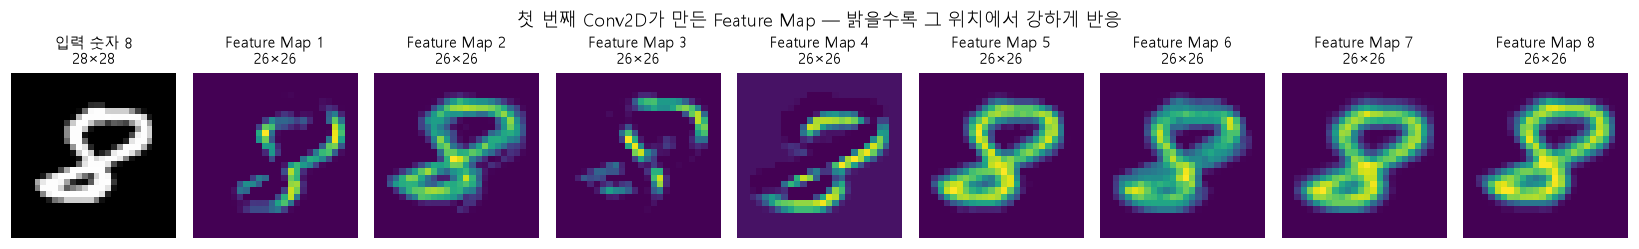

In [9]:
# ============================================================
# [결과 보기용 보조 코드 — CNN 핵심 코드가 아닙니다]
#
# 위에서 꺼낸 Feature Map 8장을 화면에 나란히 보여 줍니다.
# Python 문법을 한 줄씩 분석할 필요는 없습니다.
# 8장이 서로 어떻게 다른지만 확인하세요.
# ============================================================
fig, axes = plt.subplots(1, 9, figsize=(15, 2.4))
axes[0].imshow(one_img[0, :, :, 0], cmap="gray")
axes[0].set_title(f"입력 숫자 {y_test[one_idx]}\n28×28", fontsize=10)
axes[0].axis("off")

for c in range(8):
    axes[c + 1].imshow(conv1_out[0, :, :, c], cmap="viridis")
    axes[c + 1].set_title(f"Feature Map {c + 1}\n26×26", fontsize=10)
    axes[c + 1].axis("off")

plt.suptitle("첫 번째 Conv2D가 만든 Feature Map — 밝을수록 그 위치에서 강하게 반응", fontsize=12)
plt.tight_layout()
plt.show()


## 06-3. MaxPooling — 강한 반응은 남기고 크기는 줄이기

> ① 이미지  →  ② Conv + ReLU  →  **③ Pool ← 현재**  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

지금 들어오는 것은 **26 × 26 크기의 Feature Map 8장**입니다.
여기서 하는 일은 **2 × 2 영역마다 가장 큰 값 하나만** 남기는 것입니다.

<svg viewBox="0 0 980 420" role="img" aria-label="MaxPooling이 2×2 영역마다 가장 큰 값만 남기는 과정" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>MaxPooling — 2 × 2 영역의 가장 큰 값만 남기기</title><desc>2×4 크기의 예시 격자를 2×2 영역 두 개로 나누어 각각 가장 큰 값만 남겨 1×2 크기로 줄어드는 MaxPooling 과정을 나타낸 그림.</desc><rect x="0" y="0" width="980" height="420" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">MaxPooling — 2 × 2 영역에서 가장 큰 값 하나만 남깁니다</text><text x="490" y="58" font-size="12" fill="#6B7280" text-anchor="middle" font-weight="normal">아래 숫자는 계산 방법을 보여 주기 위한 설명용 예시입니다</text><rect x="100" y="100" width="56" height="56" fill="#FDF6EC" stroke="#8A93A0" stroke-width="1.2"/><text x="128.0" y="134.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="156" y="100" width="56" height="56" fill="#FDF6EC" stroke="#8A93A0" stroke-width="1.2"/><text x="184.0" y="134.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">8</text><rect x="212" y="100" width="56" height="56" fill="#EDF7F6" stroke="#8A93A0" stroke-width="1.2"/><text x="240.0" y="134.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">2</text><rect x="268" y="100" width="56" height="56" fill="#EDF7F6" stroke="#8A93A0" stroke-width="1.2"/><text x="296.0" y="134.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">3</text><rect x="100" y="156" width="56" height="56" fill="#FDF6EC" stroke="#8A93A0" stroke-width="1.2"/><text x="128.0" y="190.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">4</text><rect x="156" y="156" width="56" height="56" fill="#FDF6EC" stroke="#8A93A0" stroke-width="1.2"/><text x="184.0" y="190.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">2</text><rect x="212" y="156" width="56" height="56" fill="#EDF7F6" stroke="#8A93A0" stroke-width="1.2"/><text x="240.0" y="190.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">9</text><rect x="268" y="156" width="56" height="56" fill="#EDF7F6" stroke="#8A93A0" stroke-width="1.2"/><text x="296.0" y="190.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">1</text><rect x="100" y="100" width="112" height="112" fill="none" stroke="#DE8A3E" stroke-width="3"/><rect x="212" y="100" width="112" height="112" fill="none" stroke="#2E9E96" stroke-width="3"/><text x="212" y="242" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="bold">Pooling 전  (2 × 4 = 8칸)</text><text x="388" y="132" font-size="13" fill="#DE8A3E" text-anchor="start" font-weight="bold">주황 2 × 2 : { 1, 8, 4, 2 }</text><text x="388" y="158" font-size="13" fill="#77400F" text-anchor="start" font-weight="normal">→ 가장 큰 값 8 만 남김</text><text x="388" y="200" font-size="13" fill="#2E9E96" text-anchor="start" font-weight="bold">청록 2 × 2 : { 2, 3, 9, 1 }</text><text x="388" y="226" font-size="13" fill="#0E4A46" text-anchor="start" font-weight="normal">→ 가장 큰 값 9 만 남김</text><line x1="672" y1="156" x2="710" y2="156" stroke="#8A93A0" stroke-width="2.4"/><polygon points="720,156 710,150 710,162" fill="#8A93A0"/><rect x="732" y="128" width="56" height="56" fill="#FCF0E4" stroke="#8A93A0" stroke-width="1.2"/><text x="760.0" y="162.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">8</text><rect x="788" y="128" width="56" height="56" fill="#E1F3F2" stroke="#8A93A0" stroke-width="1.2"/><text x="816.0" y="162.48" font-size="18" fill="#1F2733" text-anchor="middle" font-weight="bold">9</text><text x="788" y="242" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="bold">Pooling 후  (1 × 2 = 2칸)</text><rect x="70" y="286" width="840" height="106" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="316" font-size="14" fill="#3C4552" text-anchor="middle" font-weight="bold">실제 실습에서는 26 × 26 Feature Map 8장이 13 × 13 Feature Map 8장이 됩니다.</text><text x="490" y="344" font-size="12.5" fill="#4B5563" text-anchor="middle" font-weight="normal">가로 · 세로가 절반이 되고, 장수(8장)는 그대로입니다.</text><text x="490" y="370" font-size="12.5" fill="#4B5563" text-anchor="middle" font-weight="normal">Pooling 에는 학습되는 값이 없습니다. 가장 큰 값을 고르는 일만 합니다.</text></svg>

### 왜 필요한가요?

> **강한 반응을 남기면서 Feature Map의 크기를 줄입니다.**

크기가 줄면 다음 단계의 계산도 가벼워집니다. 대신 세부 정보가 일부 사라질 수도 있습니다.

### 다음 단계에는 무엇이 넘어가나요?
`13 × 13 × 8` 이 그대로 **두 번째 Conv2D** 의 입력이 됩니다.


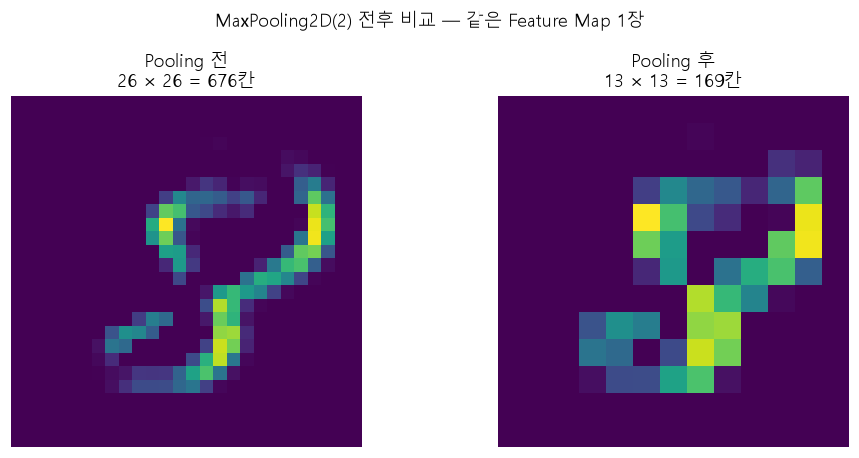

칸 수          : 676 → 169
가장 강한 반응 : 1.295 → 1.295   (강한 반응은 그대로 남습니다)


In [10]:
# ============================================================
# [결과 보기용 보조 코드 — CNN 핵심 코드가 아닙니다]
#
# 같은 Feature Map 한 장의 Pooling 전 / 후를 나란히 그려 줍니다.
# 크기 표시가 절반이 되었는지, 밝은 부분의 위치는 대체로 남아 있는지만 보세요.
# ============================================================
CH = 0                              # 첫 번째 Feature Map으로 비교

before = conv1_out[0, :, :, CH]     # Pooling 전
after = pool1_out[0, :, :, CH]      # Pooling 후

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
vmax = before.max()

axes[0].imshow(before, cmap="viridis", vmin=0, vmax=vmax)
axes[0].set_title(f"Pooling 전\n{before.shape[0]} × {before.shape[1]} = {before.size}칸", fontsize=12)
axes[0].axis("off")

axes[1].imshow(after, cmap="viridis", vmin=0, vmax=vmax)
axes[1].set_title(f"Pooling 후\n{after.shape[0]} × {after.shape[1]} = {after.size}칸", fontsize=12)
axes[1].axis("off")

plt.suptitle("MaxPooling2D(2) 전후 비교 — 같은 Feature Map 1장", fontsize=12)
plt.tight_layout()
plt.show()

print(f"칸 수          : {before.size} → {after.size}")
print(f"가장 강한 반응 : {before.max():.3f} → {after.max():.3f}   (강한 반응은 그대로 남습니다)")


## 06-4. 두 번째 Conv — 앞에서 찾은 특징을 다시 조합

> ① 이미지  →  ② Conv + ReLU  →  ③ Pool  →  **④ 두 번째 Conv + ReLU ← 현재**  →  ⑤ Pool  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

### 06-4A. 왜 두 번째 Conv가 필요한가?

두 번째 `Conv2D` 는 단순히 "또 Conv" 가 아닙니다. **들어오는 것이 다릅니다.**

| | 무엇을 입력받나요? | 크기 |
|---|---|---|
| **첫 번째 Conv** | 원본 이미지의 픽셀 밝기값 | `(28, 28, 1)` |
| **두 번째 Conv** | 첫 번째 Conv가 만든 Feature Map | `(13, 13, 8)` |

> **두 번째 Conv는 원본 이미지를 처음부터 다시 보는 것이 아닙니다.**

<svg viewBox="0 0 980 780" role="img" aria-label="첫 번째 Conv와 두 번째 Conv가 입력받는 것의 차이" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>첫 번째 Conv와 두 번째 Conv가 입력받는 것의 차이</title><desc>첫 번째 Conv는 원본 이미지의 픽셀 밝기값을 입력받고, 두 번째 Conv는 첫 번째 Conv가 만든 Feature Map을 입력받아 앞 단계의 특징을 다시 조합한다는 점을 나타낸 개념 흐름도.</desc><rect x="0" y="0" width="980" height="780" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">왜 Conv를 두 번 사용하는가?</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">두 번째 Conv는 원본 이미지를 처음부터 다시 보는 것이 아닙니다</text><rect x="50" y="74" width="880" height="46" rx="8" ry="8" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="490" y="93" font-size="11.8" fill="#77400F" text-anchor="middle" font-weight="normal">⚠ 아래의 「짧은 선 · 모서리」, 「이어진 곡선」 등은 개념 설명용 예시입니다.</text><text x="490" y="111" font-size="11.8" fill="#77400F" text-anchor="middle" font-weight="normal">실제로 각 필터가 무엇에 반응하는지는 학습 결과에 따라 달라집니다.</text><rect x="110" y="136" width="440" height="68" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="330" y="166" font-size="15" fill="#1B3A5E" text-anchor="middle" font-weight="bold">원본 숫자 이미지</text><text x="330" y="190" font-size="11.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.85">28 × 28 밝기값 1장</text><line x1="330" y1="204" x2="330" y2="230" stroke="#8A93A0" stroke-width="2"/><polygon points="330,240 324,230 336,230" fill="#8A93A0"/><text x="346" y="228" font-size="11.5" fill="#6B7280" text-anchor="start" font-weight="normal">Conv1 + ReLU</text><rect x="110" y="240" width="440" height="94" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="330" y="270" font-size="15" fill="#3B295D" text-anchor="middle" font-weight="bold">① 첫 번째 Conv — 작은 특징 찾기</text><text x="330" y="296" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">짧은 선 · 모서리 · 작은 곡선 같은 단순한 반응</text><text x="330" y="320" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">→ Feature Map 8장  (26 × 26 × 8)</text><line x1="330" y1="334" x2="330" y2="360" stroke="#8A93A0" stroke-width="2"/><polygon points="330,370 324,360 336,360" fill="#8A93A0"/><text x="346" y="358" font-size="11.5" fill="#6B7280" text-anchor="start" font-weight="normal">MaxPooling</text><rect x="110" y="370" width="440" height="60" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="330" y="396" font-size="13.5" fill="#0E4A46" text-anchor="middle" font-weight="bold">Pooling — 강한 반응을 남기고 크기 축소</text><text x="330" y="418" font-size="11.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.85">13 × 13 × 8</text><line x1="330" y1="430" x2="330" y2="456" stroke="#8A93A0" stroke-width="2"/><polygon points="330,466 324,456 336,456" fill="#8A93A0"/><text x="346" y="454" font-size="11.5" fill="#6B7280" text-anchor="start" font-weight="normal">Conv2 + ReLU</text><rect x="110" y="466" width="440" height="110" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="330" y="496" font-size="15" fill="#3B295D" text-anchor="middle" font-weight="bold">② 두 번째 Conv — 앞 특징을 다시 조합</text><text x="330" y="522" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">앞에서 만들어진 Feature Map 8장을 함께 보고</text><text x="330" y="544" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">여러 특징이 겹치는 더 복합적인 모양에 반응</text><text x="330" y="566" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">→ Feature Map 16장  (11 × 11 × 16)</text><line x1="330" y1="576" x2="330" y2="602" stroke="#8A93A0" stroke-width="2"/><polygon points="330,612 324,602 336,602" fill="#8A93A0"/><rect x="110" y="612" width="440" height="60" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="330" y="638" font-size="13.5" fill="#0E4A46" text-anchor="middle" font-weight="bold">Pooling — 다시 크기 축소</text><text x="330" y="660" font-size="11.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.85">5 × 5 × 16</text><rect x="580" y="240" width="350" height="94" rx="10" ry="10" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.5" stroke-dasharray="5 4"/><text x="755" y="272" font-size="13" fill="#3B295D" text-anchor="middle" font-weight="bold">무엇을 입력받나요?</text><text x="755" y="300" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">→ 원본 이미지의 픽셀 밝기값</text><text x="755" y="322" font-size="11" fill="#6B7280" text-anchor="middle" font-weight="normal">(28 × 28 × 1)</text><rect x="580" y="466" width="350" height="110" rx="10" ry="10" fill="#FFFFFF" stroke="#7B5EA7" stroke-width="1.5" stroke-dasharray="5 4"/><text x="755" y="496" font-size="13" fill="#3B295D" text-anchor="middle" font-weight="bold">무엇을 입력받나요?</text><text x="755" y="524" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">→ 첫 번째 Conv가 만든</text><text x="755" y="546" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="normal">Feature Map 8장 (13 × 13 × 8)</text><text x="755" y="568" font-size="11.5" fill="#77400F" text-anchor="middle" font-weight="bold">원본 이미지를 다시 보지 않습니다</text><rect x="60" y="692" width="860" height="72" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="720" font-size="14" fill="#3C4552" text-anchor="middle" font-weight="bold">첫 번째 Conv는 픽셀을 보고, 두 번째 Conv는 앞에서 찾은 특징을 봅니다.</text><text x="490" y="746" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">층을 쌓을수록 단순한 특징이 조합되어 더 복합적인 모양을 다룰 수 있게 됩니다.</text></svg>

작은 선이나 모서리만으로는 0~9를 구분하기 어렵습니다.
**그 특징들이 어떻게 조합되어 있는지**가 필요하기 때문에 Conv를 한 번 더 사용합니다.
단순한 패턴을 조합해 더 복합적인 패턴을 만드는 것이 층을 쌓는 이유입니다.


### 06-4B. 두 번째 Conv의 출력은 어디로 가나?

| 단계 | 출력 크기 | 설명 |
|---|---|---|
| ③ `pool1` 결과 | `13 × 13 × 8` | 두 번째 Conv의 **입력** |
| ④ `conv2` + ReLU | `11 × 11 × 16` | Feature Map **16장** |
| ⑤ `pool2` | `5 × 5 × 16` | 다시 크기 절반 |

이 `5 × 5 × 16` 이 다음 단계인 **Flatten** 으로 넘어갑니다.

> ① 이미지  →  ② Conv + ReLU  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  **⑤ Pool ← 지금까지 확대해서 봄**  →  ⑥ Flatten  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보


## 06-5. Flatten — 한 줄로 펼치기

> ① 이미지  →  ② Conv + ReLU  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  **⑥ Flatten ← 현재**  →  ⑦ Dense + Softmax  →  ⑧ 0~9 후보

### 무엇을 입력받나요?
`5 × 5` 크기의 Feature Map **16장**입니다.

### 왜 한 줄로 펼치나요?
`Dense` 출력층은 격자 모양이 아니라 **한 줄로 늘어선 값**을 입력으로 받기 때문입니다.
그래서 Feature Map들을 순서대로 이어 붙여 `5 × 5 × 16 = 400` 개의 숫자 한 줄로 만듭니다.

### 다음 Dense에는 무엇이 넘어가나요?
**400개의 숫자 한 줄**입니다.

> Flatten은 새로운 특징을 찾는 단계가 아니라 **모양을 바꾸는 단계**입니다.
> 새로 계산하는 것이 없고, 학습되는 값도 없습니다.

<svg viewBox="0 0 940 560" role="img" aria-label="특징맵을 한 줄로 펼치는 Flatten 개념" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:880px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>특징맵을 한 줄로 펼치는 Flatten 개념</title><desc>여러 장의 특징맵이 Flatten을 거쳐 한 줄의 숫자 목록이 되고, 그 목록이 Dense(10, softmax)를 지나 0부터 9까지의 숫자 후보 점수가 되는 과정을 나타낸 그림.</desc><rect x="0" y="0" width="940" height="560" fill="#FFFFFF"/><text x="470.0" y="34" font-size="21" fill="#1F2733" text-anchor="middle" font-weight="bold">특징맵을 한 줄로 정리합니다 (Flatten)</text><text x="470.0" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">5 × 5 크기의 특징맵 16장 → 400개의 값이 한 줄로 이어집니다</text><text x="66" y="100" font-size="13.5" fill="#0E4A46" text-anchor="start" font-weight="bold">① 두 번째 풀링을 지난 특징맵</text><rect x="120.0" y="118.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="131.0" y="118.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="142.0" y="118.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="153.0" y="118.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="164.0" y="118.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="120.0" y="129.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="131.0" y="129.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="142.0" y="129.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="153.0" y="129.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="164.0" y="129.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="120.0" y="140.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="131.0" y="140.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="142.0" y="140.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="153.0" y="140.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="164.0" y="140.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="120.0" y="151.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="131.0" y="151.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="142.0" y="151.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="153.0" y="151.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="164.0" y="151.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="120.0" y="162.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="131.0" y="162.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="142.0" y="162.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="153.0" y="162.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="164.0" y="162.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="120" y="118" width="55.0" height="55.0" fill="none" stroke="#2E9E96" stroke-width="1.4"/><text x="147.5" y="191.0" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">1번</text><rect x="216.0" y="118.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="227.0" y="118.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="238.0" y="118.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="249.0" y="118.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="260.0" y="118.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="216.0" y="129.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="227.0" y="129.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="238.0" y="129.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="249.0" y="129.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="260.0" y="129.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="216.0" y="140.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="227.0" y="140.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="238.0" y="140.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="249.0" y="140.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="260.0" y="140.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="216.0" y="151.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="227.0" y="151.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="238.0" y="151.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="249.0" y="151.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="260.0" y="151.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="216.0" y="162.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="227.0" y="162.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="238.0" y="162.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="249.0" y="162.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="260.0" y="162.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="216" y="118" width="55.0" height="55.0" fill="none" stroke="#2E9E96" stroke-width="1.4"/><text x="243.5" y="191.0" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">2번</text><rect x="312.0" y="118.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="323.0" y="118.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="334.0" y="118.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="345.0" y="118.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="356.0" y="118.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="312.0" y="129.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="323.0" y="129.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="334.0" y="129.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="345.0" y="129.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="356.0" y="129.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="312.0" y="140.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="323.0" y="140.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="334.0" y="140.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="345.0" y="140.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="356.0" y="140.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="312.0" y="151.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="323.0" y="151.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="334.0" y="151.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="345.0" y="151.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="356.0" y="151.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="312.0" y="162.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="323.0" y="162.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="334.0" y="162.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="345.0" y="162.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="356.0" y="162.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="312" y="118" width="55.0" height="55.0" fill="none" stroke="#2E9E96" stroke-width="1.4"/><text x="339.5" y="191.0" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">3번</text><rect x="408.0" y="118.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="419.0" y="118.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="430.0" y="118.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="441.0" y="118.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="452.0" y="118.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="408.0" y="129.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="419.0" y="129.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="430.0" y="129.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="441.0" y="129.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="452.0" y="129.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="408.0" y="140.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="419.0" y="140.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="430.0" y="140.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="441.0" y="140.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="452.0" y="140.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="408.0" y="151.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="419.0" y="151.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="430.0" y="151.0" width="11.0" height="11.0" fill="rgb(84,84,84)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="441.0" y="151.0" width="11.0" height="11.0" fill="rgb(179,179,179)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="452.0" y="151.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="408.0" y="162.0" width="11.0" height="11.0" fill="rgb(122,122,122)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="419.0" y="162.0" width="11.0" height="11.0" fill="rgb(236,236,236)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="430.0" y="162.0" width="11.0" height="11.0" fill="rgb(160,160,160)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="441.0" y="162.0" width="11.0" height="11.0" fill="rgb(255,255,255)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="452.0" y="162.0" width="11.0" height="11.0" fill="rgb(217,217,217)" stroke="#E4E8EE" stroke-width="0.7"/><rect x="408" y="118" width="55.0" height="55.0" fill="none" stroke="#2E9E96" stroke-width="1.4"/><text x="435.5" y="191.0" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">4번</text><text x="534" y="150" font-size="22" fill="#6B7280" text-anchor="start" font-weight="normal">…</text><text x="578" y="148" font-size="14" fill="#0E4A46" text-anchor="start" font-weight="bold">모두 16장</text><text x="578" y="170" font-size="12" fill="#6B7280" text-anchor="start" font-weight="normal">각 장의 크기는 5 × 5</text><line x1="470" y1="212" x2="470" y2="249" stroke="#8A93A0" stroke-width="2"/><polygon points="470,258 464,248 476,248" fill="#8A93A0"/><text x="484" y="239.0" font-size="12.5" fill="#6B7280" text-anchor="start" font-weight="normal">Flatten() — 순서대로 한 줄로 펼침</text><text x="66" y="288" font-size="13.5" fill="#4B5563" text-anchor="start" font-weight="bold">② 한 줄로 펼친 특징 목록</text><rect x="129.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="158.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.00</text><rect x="191.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="220.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.83</text><rect x="253.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="282.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.12</text><rect x="315.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="344.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.00</text><rect x="377.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="406.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.57</text><rect x="439.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="468.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.91</text><rect x="501.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="530.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.00</text><rect x="563.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="592.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.34</text><rect x="625.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="654.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.06</text><rect x="687.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="716.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">0.72</text><rect x="749.0" y="302" width="58.0" height="44" rx="6" ry="6" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="778.0" y="330" font-size="13.5" fill="#4B5563" text-anchor="middle" font-weight="normal">…</text><text x="470.0" y="370" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">5 × 5 × 16 = 400개의 값 (실제 개수는 코드로 확인합니다)</text><line x1="470" y1="380" x2="470" y2="415" stroke="#8A93A0" stroke-width="2"/><polygon points="470,424 464,414 476,414" fill="#8A93A0"/><text x="484" y="406.0" font-size="12.5" fill="#6B7280" text-anchor="start" font-weight="normal">Dense(10, activation="softmax")</text><text x="66" y="452" font-size="13.5" fill="#77400F" text-anchor="start" font-weight="bold">③ 0~9 숫자 후보 점수</text><rect x="90.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="125.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">0</text><text x="125.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="166.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="201.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">1</text><text x="201.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="242.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="277.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">2</text><text x="277.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="318.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="353.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">3</text><text x="353.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="394.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="429.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">4</text><text x="429.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="470.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="505.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">5</text><text x="505.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="546.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="581.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">6</text><text x="581.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="622.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="657.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">7</text><text x="657.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="698.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.6"/><text x="733.0" y="490" font-size="15" fill="#77400F" text-anchor="middle" font-weight="bold">8</text><text x="733.0" y="510" font-size="11.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><rect x="774.0" y="466" width="70.0" height="54" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><text x="809.0" y="490" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">9</text><text x="809.0" y="510" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">점수</text><text x="470.0" y="544" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="normal">가장 높은 점수의 숫자를 분류 결과로 제안합니다</text></svg>


---
# 07. 새로운 숫자를 분류해 보기

## 07-1. Dense + Softmax — 0~9 후보 점수 만들기

> ① 이미지  →  ② Conv + ReLU  →  ③ Pool  →  ④ 두 번째 Conv + ReLU  →  ⑤ Pool  →  ⑥ Flatten  →  **⑦ Dense + Softmax ← 현재**  →  ⑧ 0~9 후보

### 무엇을 입력받나요?
Flatten이 만든 **400개의 숫자** 한 줄.

| 순서 | 단계 | 나오는 값 |
|---|---|---|
| 입력 | Flatten 결과 | 400개 숫자 |
| ⑦-1 | `Dense(10)` | 10개의 원래 점수 |
| ⑦-2 | `softmax` | ⑧ 0~9 후보 점수 (합 = 1.00) |

`Dense` 는 CNN이 앞에서 찾아낸 특징을 이용하여
**0~9 숫자 각각의 후보 점수를 만드는 출력 부분**입니다.

### 왜 10개인가요?
우리가 고르려는 후보가 `0, 1, 2, ... , 9` 로 **10개**이기 때문입니다.

### 무엇을 확인하면 되나요?

> CNN이 처음부터 "8" 이라는 글자를 만드는 것이 아니라,
> **0~9 각각에 대한 점수를 만들고 비교**한다는 점입니다.

> ⚠️ Softmax 출력값은 0~9 후보를 **비교하기 쉬운 점수 형태**로 만든 것입니다.
> 합이 1이 되지만 "8일 확률 92%", "신뢰도 92%" 처럼 단정해서 읽지 않습니다.


## 07-2. ★ CNN 추론의 핵심은 두 줄입니다

학습이 끝난 CNN에 새 이미지를 넣어 답 후보를 얻는 부분입니다.
아래 셀은 화면에 출력이 없습니다. 계산 결과는 다음 셀에서 확인합니다.


In [11]:
# ============================================================
# ★ [추론] 학습이 끝난 CNN에 새로운 숫자 이미지 한 장 넣기
#
# 무엇이 들어오나요 : 학습에 사용하지 않은 테스트 이미지 한 장 (one_img)
# 무엇을 하나요     : 필터나 Weight를 더 이상 수정하지 않고,
#                     Conv → Pool → Conv → Pool → Flatten → Dense + Softmax
#                     순서로 Forward 만 수행합니다.
# 왜 필요한가요     : 실제로 CNN을 사용할 때 하는 일이 바로 이것입니다.
# 무엇이 나가나요   : 숫자 0~9 각각에 대한 후보 점수 10개
# 다음 단계         : 가장 큰 점수의 자리를 찾아 예측 후보로 고릅니다.
# ============================================================
scores = model.predict(one_img, verbose=0)[0]     # 0~9 후보 점수 10개

# 10개 후보 점수 중 가장 큰 값이 '몇 번째 자리'에 있는지 찾습니다.
#
# 예:
#   숫자 0 → 0.00
#   숫자 1 → 0.01
#   ...
#   숫자 8 → 0.95   ← 가장 큼
#   숫자 9 → 0.02
#
# 가장 큰 값이 8번 자리에 있으므로 최종 예측 후보는 8입니다.
# (argmax 라는 Python 문법을 따로 공부할 필요는 없습니다.)
best = int(scores.argmax())


## 07-3. 결과를 보기 위한 보조 코드

아래 코드는 위에서 계산한 후보 점수 10개를 막대그래프와 표로 보여 주기 위한 코드입니다.
CNN 알고리즘 자체가 아니므로 Python 문법을 분석하지 않아도 됩니다.


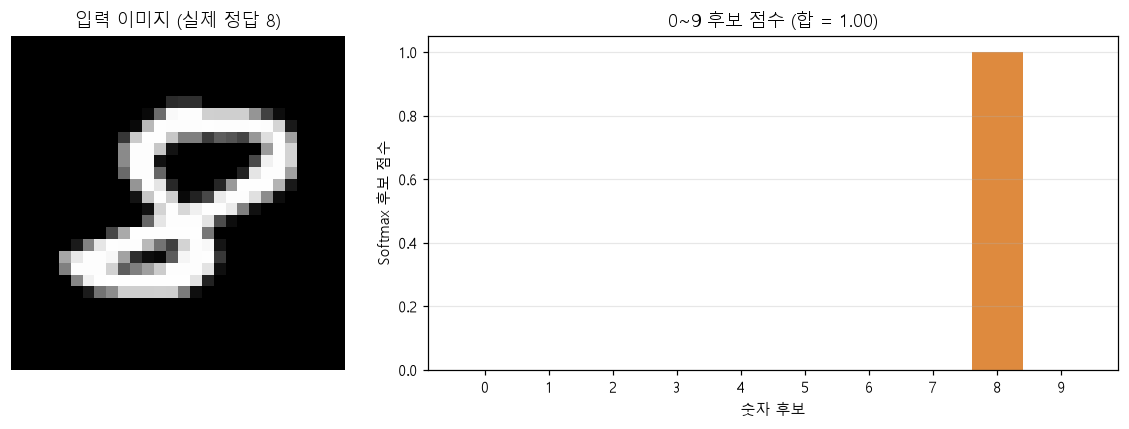

0~9 후보 점수
----------------------------------
  0 : 0.0000
  1 : 0.0000
  2 : 0.0002
  3 : 0.0001
  4 : 0.0000
  5 : 0.0004
  6 : 0.0000
  7 : 0.0000
  8 : 0.9990  ← 가장 높은 후보
  9 : 0.0003
----------------------------------
  합계 : 1.0000

→ 가장 높은 8 를 예측 후보로 선택합니다.


In [12]:
# ============================================================
# [결과 보기용 보조 코드 — CNN 핵심 코드가 아닙니다]
#
# 위에서 구한 scores(0~9 후보 점수)와 best(가장 높은 후보)를
# 막대그래프와 표로 보여 줍니다.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), gridspec_kw={"width_ratios": [1, 1.9]})

axes[0].imshow(one_img[0, :, :, 0], cmap="gray")
axes[0].set_title(f"입력 이미지 (실제 정답 {y_test[one_idx]})", fontsize=12)
axes[0].axis("off")

axes[1].bar(range(10), scores,
            color=["#DE8A3E" if d == best else "#B9C0CA" for d in range(10)])
axes[1].set_xticks(range(10))
axes[1].set_xlabel("숫자 후보"); axes[1].set_ylabel("Softmax 후보 점수")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("0~9 후보 점수 (합 = 1.00)", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("0~9 후보 점수")
print("-" * 34)
for d in range(10):
    mark = "  ← 가장 높은 후보" if d == best else ""
    print(f"  {d} : {scores[d]:.4f}{mark}")
print("-" * 34)
print(f"  합계 : {scores.sum():.4f}")
print()
print(f"→ 가장 높은 {best} 를 예측 후보로 선택합니다.")


## 07-4. 전체 테스트 데이터에서는 얼마나 맞힐까?

학습에 한 번도 사용하지 않은 테스트 이미지 **10,000장**으로 확인합니다.

그리고 **CNN도 틀립니다.** 틀린 사례를 몇 장만 직접 봅니다.

> 그림을 보면서 생각해 보세요.
> **왜 헷갈렸을까요?** — 글자 모양이 비슷한가요, 아니면 사람은 쉽게 읽을 수 있는 글씨인가요?


Test Accuracy : 0.9807   (10,000장 중 9,807장 정답)
틀린 이미지   : 193장



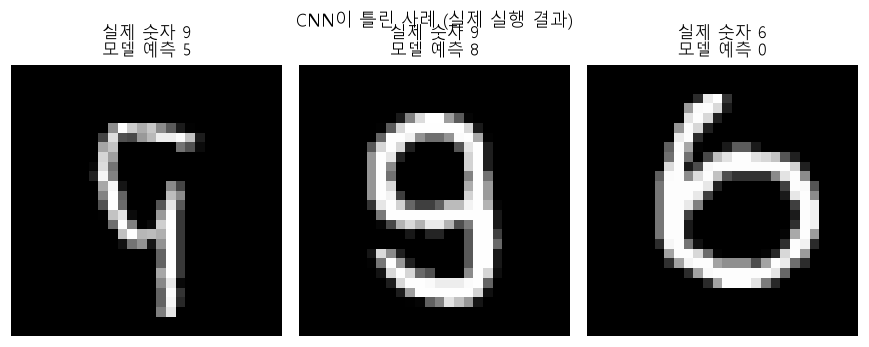

실제 숫자 9  →  모델 예측 5
실제 숫자 9  →  모델 예측 8
실제 숫자 6  →  모델 예측 0

사람이 봐도 애매하게 쓰인 글씨도 있고, 사람은 쉽게 읽는데 모델이 틀린 경우도 있습니다.
CNN도 완벽하지 않으며 결과를 사람이 검토해야 합니다.


In [13]:
# ============================================================
# [결과 보기용 보조 코드 — CNN 핵심 코드가 아닙니다]
#
# 테스트 10,000장의 정확도를 계산하고, 틀린 사례 3장을 그려 줍니다.
# 숫자와 그림만 확인하세요.
# ============================================================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
y_pred = model.predict(x_test, verbose=0).argmax(axis=1)

n_wrong = int((y_pred != y_test).sum())
print(f"Test Accuracy : {test_acc:.4f}   (10,000장 중 {10000 - n_wrong:,}장 정답)")
print(f"틀린 이미지   : {n_wrong:,}장")
print()

# 틀린 사례를 앞에서부터 3장만 봅니다.
wrong = np.where(y_pred != y_test)[0][:3]

fig, axes = plt.subplots(1, 3, figsize=(8, 3.2))
for ax, i in zip(axes, wrong):
    ax.imshow(x_test[i, :, :, 0], cmap="gray")
    ax.set_title(f"실제 숫자 {y_test[i]}\n모델 예측 {y_pred[i]}", fontsize=11)
    ax.axis("off")
plt.suptitle("CNN이 틀린 사례 (실제 실행 결과)", fontsize=12)
plt.tight_layout()
plt.show()

for i in wrong:
    print(f"실제 숫자 {y_test[i]}  →  모델 예측 {y_pred[i]}")
print()
print("사람이 봐도 애매하게 쓰인 글씨도 있고, 사람은 쉽게 읽는데 모델이 틀린 경우도 있습니다.")
print("CNN도 완벽하지 않으며 결과를 사람이 검토해야 합니다.")


---
# 08. 핵심 정리

## 08-1. ★ 예측 흐름 (Forward)

맨 처음에 본 지도입니다. 지금은 각 상자가 무슨 뜻인지 알 수 있어야 합니다.

<svg viewBox="0 0 1040 760" role="img" aria-label="이번 실습에서 만드는 CNN 전체 구조" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:940px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>이번 실습에서 만드는 CNN 전체 구조</title><desc>윗줄은 CNN 특징 추출 부분으로 숫자 이미지가 Conv2D+ReLU와 MaxPooling2D를 두 번 거치는 과정을, 아랫줄은 분류 출력 부분으로 Flatten과 Dense+Softmax를 거쳐 0~9 후보 점수가 되는 과정을 각 단계 출력 크기와 함께 나타낸 흐름도.</desc><rect x="0" y="0" width="1040" height="760" fill="#FFFFFF"/><text x="520" y="36" font-size="21" fill="#1F2733" text-anchor="middle" font-weight="bold">이번 실습에서 만드는 CNN</text><text x="520" y="60" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">위 줄에서 특징을 찾고, 아래 줄에서 0~9 중 하나를 고릅니다</text><rect x="30" y="80" width="980" height="262" rx="14" ry="14" fill="#FBFAFD" stroke="#7B5EA7" stroke-width="1.6" stroke-dasharray="7 5"/><text x="52" y="108" font-size="15" fill="#3B295D" text-anchor="start" font-weight="bold">★ CNN 특징 추출 — 이미지에서 특징을 찾아내는 부분</text><rect x="36" y="132" width="168" height="124" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="120.0" y="160" font-size="13.5" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 숫자 이미지</text><text x="120.0" y="184" font-size="10" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.85">Input(shape=(28, 28, 1))</text><text x="120.0" y="206" font-size="10.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.75">0~1 로 맞춘 밝기값</text><text x="120.0" y="226" font-size="10.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.75">흑백 1장</text><text x="120.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="120.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">28 × 28 × 1</text><line x1="208" y1="194" x2="222" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="232,194 222,188 222,200" fill="#8A93A0"/><rect x="236" y="132" width="168" height="124" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="320.0" y="160" font-size="13.5" fill="#3B295D" text-anchor="middle" font-weight="bold">② Conv + ReLU</text><text x="320.0" y="184" font-size="10" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">Conv2D(8, 3, "relu")</text><text x="320.0" y="206" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">3×3 필터 8개가 이동</text><text x="320.0" y="226" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">음수 반응은 ReLU가 0으로</text><text x="320.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="320.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">26 × 26 × 8</text><line x1="408" y1="194" x2="422" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="432,194 422,188 422,200" fill="#8A93A0"/><rect x="436" y="132" width="168" height="124" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="520.0" y="160" font-size="13.5" fill="#0E4A46" text-anchor="middle" font-weight="bold">③ MaxPooling</text><text x="520.0" y="184" font-size="10" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.85">MaxPooling2D(2)</text><text x="520.0" y="206" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.75">2×2 중 가장 큰 값만</text><text x="520.0" y="226" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.75">크기를 절반으로</text><text x="520.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="520.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">13 × 13 × 8</text><line x1="608" y1="194" x2="622" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="632,194 622,188 622,200" fill="#8A93A0"/><rect x="636" y="132" width="168" height="124" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="720.0" y="160" font-size="13" fill="#3B295D" text-anchor="middle" font-weight="bold">④ 두 번째 Conv + ReLU</text><text x="720.0" y="184" font-size="10" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">Conv2D(16, 3, "relu")</text><text x="720.0" y="206" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">앞 Feature Map 8장을</text><text x="720.0" y="226" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.75">함께 보고 다시 조합</text><text x="720.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="720.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">11 × 11 × 16</text><line x1="808" y1="194" x2="822" y2="194" stroke="#8A93A0" stroke-width="2"/><polygon points="832,194 822,188 822,200" fill="#8A93A0"/><rect x="836" y="132" width="168" height="124" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="920.0" y="160" font-size="13.5" fill="#0E4A46" text-anchor="middle" font-weight="bold">⑤ MaxPooling</text><text x="920.0" y="184" font-size="10" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.85">MaxPooling2D(2)</text><text x="920.0" y="206" font-size="10.5" fill="#0E4A46" text-anchor="middle" font-weight="normal" opacity="0.75">다시 크기를 절반으로</text><text x="920.0" y="284" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="920.0" y="306" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">5 × 5 × 16</text><line x1="520" y1="342" x2="520" y2="374" stroke="#8A93A0" stroke-width="2"/><polygon points="520,384 514,374 526,374" fill="#8A93A0"/><text x="538" y="368" font-size="12" fill="#6B7280" text-anchor="start" font-weight="normal">5 × 5 크기의 Feature Map 16장이 그대로 넘어갑니다</text><rect x="30" y="392" width="980" height="218" rx="14" ry="14" fill="#FFFDF9" stroke="#DE8A3E" stroke-width="1.6" stroke-dasharray="7 5"/><text x="52" y="420" font-size="15" fill="#77400F" text-anchor="start" font-weight="bold">분류 출력 — 찾은 특징으로 0~9 후보 점수를 만드는 부분</text><rect x="140" y="444" width="220" height="104" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="250" y="474" font-size="14" fill="#4B5563" text-anchor="middle" font-weight="bold">⑥ Flatten</text><text x="250" y="500" font-size="10.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.85">Flatten()</text><text x="250" y="522" font-size="10.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.75">5 × 5 × 16 = 400개 숫자 한 줄</text><text x="250" y="574" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="250" y="596" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">400</text><rect x="410" y="444" width="220" height="104" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="520" y="474" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">⑦ Dense + Softmax</text><text x="520" y="500" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.85">Dense(10, activation="softmax")</text><text x="520" y="522" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.75">0~9 각각의 후보 점수 10개</text><text x="520" y="574" font-size="10.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기</text><text x="520" y="596" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">10</text><rect x="680" y="444" width="220" height="104" rx="10" ry="10" fill="#FFFFFF" stroke="#DE8A3E" stroke-width="1.5" stroke-dasharray="5 4"/><text x="790" y="474" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">⑧ 0~9 후보 점수</text><text x="790" y="500" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.85">가장 높은 점수의 숫자를</text><text x="790" y="522" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.75">분류 결과로 제안</text><text x="790" y="586" font-size="11" fill="#6B7280" text-anchor="middle" font-weight="normal">점수는 후보일 뿐 정답 선언이 아닙니다</text><line x1="364" y1="496" x2="396" y2="496" stroke="#8A93A0" stroke-width="2"/><polygon points="406,496 396,490 396,502" fill="#8A93A0"/><line x1="634" y1="496" x2="666" y2="496" stroke="#8A93A0" stroke-width="2"/><polygon points="676,496 666,490 666,502" fill="#8A93A0"/><rect x="30" y="630" width="980" height="88" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="520" y="656" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">출력 크기 흐름</text><text x="520" y="684" font-size="14.5" fill="#3C4552" text-anchor="middle" font-weight="bold">28×28×1  →  26×26×8  →  13×13×8  →  11×11×16  →  5×5×16  →  400  →  10</text><text x="520" y="708" font-size="11.5" fill="#6B7280" text-anchor="middle" font-weight="normal">※ 그림의 「Conv + ReLU」는 코드에서 Conv2D(..., activation="relu") 한 줄 안에 함께 들어 있습니다</text></svg>

| 단계 | 하는 일 | 출력 |
|---|---|---|
| ① 이미지 | 28×28 밝기값 1장 | `28 × 28 × 1` |
| ② Conv + ReLU | 3×3 필터 8개가 이동하며 계산, 음수는 0 | `26 × 26 × 8` |
| ③ Pooling | 2×2 중 가장 큰 값만 | `13 × 13 × 8` |
| ④ 두 번째 Conv + ReLU | 앞 Feature Map 8장을 조합 | `11 × 11 × 16` |
| ⑤ Pooling | 다시 절반으로 | `5 × 5 × 16` |
| ⑥ Flatten | 한 줄로 펼치기 | `400` |
| ⑦ Dense + Softmax | 0~9 후보 점수 | `10` |
| ⑧ 후보 선택 | 가장 높은 점수의 숫자 | 1개 |


## 08-2. ★ 학습 흐름 (Learning)

<svg viewBox="0 0 980 700" role="img" aria-label="CNN 학습이 반복되는 한 바퀴" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>CNN 학습이 반복되는 한 바퀴</title><desc>이미지가 CNN Forward를 지나 0~9 후보 점수가 되고, 정답과 비교해 Loss를 계산한 뒤 역전파와 Optimizer를 거쳐 Conv 필터와 Dense Weight/Bias가 수정되고 다시 Forward로 돌아오는 학습 반복 과정을 나타낸 순환 흐름도.</desc><rect x="0" y="0" width="980" height="700" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">CNN은 어떻게 학습하나 — 반복되는 한 바퀴</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">model.fit() 한 줄 안에서 아래 과정이 계속 반복됩니다</text><rect x="70" y="86" width="190" height="92" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="165" y="124" font-size="14" fill="#1B3A5E" text-anchor="middle" font-weight="bold">① 이미지 한 묶음</text><text x="165" y="150" font-size="11.5" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.85">x_train (128장씩)</text><line x1="264" y1="132" x2="296" y2="132" stroke="#8A93A0" stroke-width="2"/><polygon points="306,132 296,126 296,138" fill="#8A93A0"/><rect x="306" y="86" width="354" height="92" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="483" y="118" font-size="15" fill="#3B295D" text-anchor="middle" font-weight="bold">② CNN Forward</text><text x="483" y="144" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">Conv → Pool → Conv → Pool</text><text x="483" y="166" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal">→ Flatten → Dense + Softmax</text><line x1="664" y1="132" x2="696" y2="132" stroke="#8A93A0" stroke-width="2"/><polygon points="706,132 696,126 696,138" fill="#8A93A0"/><rect x="706" y="86" width="204" height="92" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="808" y="124" font-size="14" fill="#77400F" text-anchor="middle" font-weight="bold">③ 0~9 후보 점수</text><text x="808" y="150" font-size="11.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.85">10개의 점수</text><line x1="808" y1="178" x2="808" y2="212" stroke="#8A93A0" stroke-width="2"/><polygon points="808,222 802,212 814,212" fill="#8A93A0"/><rect x="706" y="222" width="204" height="76" rx="10" ry="10" fill="#FFFFFF" stroke="#CBD0D8" stroke-width="1.5"/><text x="808" y="252" font-size="14" fill="#4B5563" text-anchor="middle" font-weight="bold">④ 정답과 비교</text><text x="808" y="276" font-size="11.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.85">y_train (실제 숫자)</text><line x1="808" y1="298" x2="808" y2="332" stroke="#8A93A0" stroke-width="2"/><polygon points="808,342 802,332 814,332" fill="#8A93A0"/><rect x="706" y="342" width="204" height="76" rx="10" ry="10" fill="#FBEEEA" stroke="#C4633F" stroke-width="1.5"/><text x="808" y="372" font-size="15" fill="#7A2E12" text-anchor="middle" font-weight="bold">⑤ Loss</text><text x="808" y="396" font-size="11.5" fill="#7A2E12" text-anchor="middle" font-weight="normal">틀린 정도를 숫자 하나로</text><line x1="808" y1="418" x2="808" y2="452" stroke="#8A93A0" stroke-width="2"/><polygon points="808,462 802,452 814,452" fill="#8A93A0"/><rect x="706" y="462" width="204" height="92" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="808" y="492" font-size="14" fill="#3B295D" text-anchor="middle" font-weight="bold">⑥ 역전파</text><text x="808" y="516" font-size="11" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">Backpropagation</text><text x="808" y="538" font-size="11" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.85">어느 값을 어느 쪽으로</text><line x1="702" y1="508" x2="674" y2="508" stroke="#8A93A0" stroke-width="2"/><polygon points="664,508 674,502 674,514" fill="#8A93A0"/><rect x="430" y="462" width="230" height="92" rx="10" ry="10" fill="#E1F3F2" stroke="#2E9E96" stroke-width="1.5"/><text x="545" y="498" font-size="14" fill="#0E4A46" text-anchor="middle" font-weight="bold">⑦ Optimizer</text><text x="545" y="524" font-size="11.5" fill="#0E4A46" text-anchor="middle" font-weight="normal">실제로 값을 조금씩 수정</text><line x1="426" y1="508" x2="398" y2="508" stroke="#8A93A0" stroke-width="2"/><polygon points="388,508 398,502 398,514" fill="#8A93A0"/><rect x="90" y="462" width="294" height="92" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="237" y="492" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="bold">⑧ Conv Filter  +</text><text x="237" y="516" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="bold">Dense Weight / Bias 수정</text><text x="237" y="540" font-size="11" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.8">학습으로 바뀌는 값은 이 두 가지뿐</text><path d="M 90 508 L 42 508 L 42 132 L 58 132" fill="none" stroke="#8A93A0" stroke-width="2"/><polygon points="68,132 58,126 58,138" fill="#8A93A0"/><text x="96" y="582" font-size="11.5" fill="#6B7280" text-anchor="start" font-weight="normal">수정된 값으로 다시 Forward (반복)</text><rect x="150" y="232" width="480" height="170" rx="12" ry="12" fill="#FFFDF9" stroke="#DE8A3E" stroke-width="2"/><text x="390" y="268" font-size="16" fill="#77400F" text-anchor="middle" font-weight="bold">★ 여기가 가장 중요합니다</text><text x="390" y="304" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="normal">Optimizer가 Conv 필터 값을 바꾸면</text><text x="390" y="330" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="normal">다음 Forward에서 만들어지는 Feature Map도 달라지고</text><text x="390" y="356" font-size="13.5" fill="#77400F" text-anchor="middle" font-weight="normal">그 결과 0~9 후보 점수도 함께 달라집니다.</text><text x="390" y="386" font-size="12" fill="#6B7280" text-anchor="middle" font-weight="normal">학습은 같은 CNN을 조금씩 고쳐 가는 과정입니다.</text><rect x="70" y="606" width="840" height="64" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="632" font-size="13" fill="#3C4552" text-anchor="middle" font-weight="bold">학습되는 값 :  Conv2D 필터  ·  Dense Weight / Bias</text><text x="490" y="656" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal">학습할 값이 없는 단계 :  ReLU · MaxPooling · Flatten  (값을 고르거나 모양만 바꿉니다)</text></svg>

| 순서 | 단계 | 하는 일 |
|---|---|---|
| ① ~ ③ | Forward | 이미지를 넣어 0~9 후보 점수를 계산 |
| ④ | 정답과 비교 | 실제 정답 숫자와 맞춰 봄 |
| ⑤ | Loss | 틀린 정도를 숫자 하나로 |
| ⑥ | 역전파 | 어느 값을 어느 쪽으로 바꿔야 하는지 계산 |
| ⑦ | Optimizer | 실제로 값을 조금씩 수정 |
| ⑧ | 값 수정 | **Conv Filter + Dense Weight/Bias** |


## 08-3. ★ Forward와 Learning은 어떻게 연결되나?

이번 실습에서 **가장 중요한 연결**입니다.

<svg viewBox="0 0 980 380" role="img" aria-label="Conv 필터 수정이 Feature Map과 후보 점수와 Loss로 이어지는 고리" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>Forward와 Learning은 하나의 고리</title><desc>Conv 필터가 수정되면 Feature Map이 달라지고, Flatten 값과 0~9 후보 점수, 그리고 Loss까지 함께 달라져 다시 필터 수정으로 돌아오는 순환 구조를 나타낸 그림.</desc><rect x="0" y="0" width="980" height="380" fill="#FFFFFF"/><text x="490" y="34" font-size="20" fill="#1F2733" text-anchor="middle" font-weight="bold">Forward 와 Learning 은 하나의 고리입니다</text><text x="490" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">Conv 필터가 바뀌면 그 뒤 단계가 모두 함께 달라집니다</text><rect x="20" y="96" width="168" height="104" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="104.0" y="138" font-size="12.5" fill="#77400F" text-anchor="middle" font-weight="bold">① Conv Filter 수정</text><text x="104.0" y="164" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.8">학습으로 값이 바뀜</text><line x1="191" y1="148" x2="200" y2="148" stroke="#8A93A0" stroke-width="2"/><polygon points="210,148 200,142 200,154" fill="#8A93A0"/><rect x="213" y="96" width="168" height="104" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="297.0" y="138" font-size="12.5" fill="#3B295D" text-anchor="middle" font-weight="bold">② Feature Map 변화</text><text x="297.0" y="164" font-size="10.5" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.8">반응하는 위치가 달라짐</text><line x1="384" y1="148" x2="393" y2="148" stroke="#8A93A0" stroke-width="2"/><polygon points="403,148 393,142 393,154" fill="#8A93A0"/><rect x="406" y="96" width="168" height="104" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490.0" y="138" font-size="12.5" fill="#4B5563" text-anchor="middle" font-weight="bold">③ Flatten 값 변화</text><text x="490.0" y="164" font-size="10.5" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.8">400개 숫자가 달라짐</text><line x1="577" y1="148" x2="586" y2="148" stroke="#8A93A0" stroke-width="2"/><polygon points="596,148 586,142 586,154" fill="#8A93A0"/><rect x="599" y="96" width="168" height="104" rx="10" ry="10" fill="#FFFDF9" stroke="#DE8A3E" stroke-width="1.5"/><text x="683.0" y="138" font-size="12.5" fill="#77400F" text-anchor="middle" font-weight="bold">④ 0~9 후보 점수 변화</text><text x="683.0" y="164" font-size="10.5" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.8">예측이 달라짐</text><line x1="770" y1="148" x2="779" y2="148" stroke="#8A93A0" stroke-width="2"/><polygon points="789,148 779,142 779,154" fill="#8A93A0"/><rect x="792" y="96" width="168" height="104" rx="10" ry="10" fill="#FBEEEA" stroke="#C4633F" stroke-width="1.5"/><text x="876.0" y="138" font-size="12.5" fill="#7A2E12" text-anchor="middle" font-weight="bold">⑤ Loss 변화</text><text x="876.0" y="164" font-size="10.5" fill="#7A2E12" text-anchor="middle" font-weight="normal" opacity="0.8">정답과의 차이가 달라짐</text><path d="M 876 200 L 876 254 L 104 254 L 104 220" fill="none" stroke="#8A93A0" stroke-width="2"/><polygon points="104,210 98,220 110,220" fill="#8A93A0"/><text x="490" y="278" font-size="12.5" fill="#6B7280" text-anchor="middle" font-weight="normal">다시 역전파 + Optimizer 가 필터를 수정합니다  (반복)</text><rect x="70" y="300" width="840" height="62" rx="12" ry="12" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="490" y="328" font-size="13.5" fill="#3C4552" text-anchor="middle" font-weight="bold">학습과 예측은 서로 다른 두 가지가 아닙니다.</text><text x="490" y="352" font-size="12.5" fill="#4B5563" text-anchor="middle" font-weight="normal">같은 CNN을 반복해서 조금씩 고쳐 가는 하나의 과정입니다.</text></svg>

> **Conv 필터가 바뀌면 다음 Forward에서 Feature Map도 달라지고,
> 그 뒤의 Flatten 값 · 후보 점수 · Loss 까지 모두 함께 달라집니다.**

그래서 학습이 진행될수록 Loss가 줄어들고, 0~9를 더 잘 구분하게 됩니다.

### 학습과 추론은 무엇이 다른가요?

| | 학습 (`model.fit`) | 추론 (`model.predict`) |
|---|---|---|
| Forward | 한다 | 한다 |
| 정답과 비교 · Loss | 한다 | 하지 않는다 |
| 필터 / Weight 수정 | **한다** | **하지 않는다** |


## 08-4. 자기 점검 — 아래를 내 말로 설명할 수 있나요?

1. 이미지는 픽셀 숫자로 이루어져 있다.
2. `Conv2D` 의 3×3 필터가 이미지의 작은 영역을 본다.
3. 같은 위치끼리 곱한 값을 모두 더하면 Feature Map의 **한 칸**이 만들어진다.
4. 필터를 이동하면서 같은 계산을 반복하면 Feature Map **한 장**이 만들어진다.
5. 필터가 8개면 서로 다른 Feature Map **8장**이 만들어진다.
6. ReLU는 음수를 0으로 바꾸고 양수는 그대로 전달한다.
7. Pooling은 강한 반응을 남기면서 Feature Map의 크기를 줄인다. 학습되는 값은 없다.
8. 두 번째 Conv는 원본 이미지가 아니라 **앞에서 만들어진 Feature Map**을 입력받는다.
9. 마지막 Feature Map들을 Flatten하면 Dense가 받을 **한 줄의 숫자 400개**가 된다.
10. Dense와 Softmax가 0~9 각각의 후보 점수를 만든다.
11. Loss는 예측과 정답이 얼마나 다른지를 숫자 하나로 나타낸 값이다.
12. 역전파는 어느 값을 어느 쪽으로 바꿔야 Loss가 줄어드는지를 계산한다.
13. Optimizer는 Conv 필터와 Dense Weight/Bias를 수정한다.
14. **Conv 필터가 바뀌면 다음 Forward에서 Feature Map도 바뀐다.**
15. 추론에서는 Forward만 수행하고 값을 수정하지 않는다.

이 열다섯 가지가 자연스럽게 나온다면 이번 실습은 성공입니다.


---
## 참고 — 이번 실습과 실제 영수증 OCR의 차이

MNIST에서 정확도 98%가 나왔다고 해서, **실제 영수증에서 금액을 98% 정확하게 읽는다는 뜻은 아닙니다.**

<svg viewBox="0 0 940 764" role="img" aria-label="MNIST 실습 범위와 실제 영수증 OCR 범위의 차이" xmlns="http://www.w3.org/2000/svg" style="width:100%;max-width:900px;height:auto;display:block;margin:0 auto;font-family:'Malgun Gothic','Noto Sans KR','NanumGothic','Apple SD Gothic Neo',sans-serif;"><title>MNIST 실습 범위와 실제 영수증 OCR 범위의 차이</title><desc>왼쪽에는 28×28 숫자 한 글자를 CNN으로 분류하는 이번 실습 범위를, 오른쪽에는 이미지 입력부터 사람 확인까지 이어지는 실제 영수증 OCR 8단계를 나란히 두고 이번 실습이 그중 시각적 특징 추출과 숫자 후보 분류 부분에 해당함을 나타낸 그림.</desc><rect x="0" y="0" width="940" height="764" fill="#FFFFFF"/><text x="470.0" y="34" font-size="21" fill="#1F2733" text-anchor="middle" font-weight="bold">이번 실습은 영수증 OCR 전체가 아닙니다</text><text x="470.0" y="58" font-size="13" fill="#6B7280" text-anchor="middle" font-weight="normal">CNN을 이용한 이미지 특징 추출과 숫자 후보 분류 부분을 확인하는 실습입니다</text><rect x="46" y="88" width="380" height="632" rx="10" ry="10" fill="#FFFFFF" stroke="#CBD0D8" stroke-width="1.5"/><text x="236" y="118" font-size="16.5" fill="#1B3A5E" text-anchor="middle" font-weight="bold">이번 실습 (MNIST)</text><rect x="76" y="148" width="320" height="74" rx="10" ry="10" fill="#E8F0FB" stroke="#4C78A8" stroke-width="1.5"/><text x="236" y="180" font-size="15" fill="#1B3A5E" text-anchor="middle" font-weight="bold">28 × 28 숫자 한 글자</text><text x="236" y="202" font-size="12" fill="#1B3A5E" text-anchor="middle" font-weight="normal" opacity="0.8">이미 잘려 있고 가운데 정렬됨</text><line x1="236" y1="222" x2="236" y2="249" stroke="#8A93A0" stroke-width="2"/><polygon points="236,258 230,248 242,248" fill="#8A93A0"/><rect x="76" y="258" width="320" height="74" rx="10" ry="10" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.5"/><text x="236" y="290" font-size="15" fill="#3B295D" text-anchor="middle" font-weight="bold">CNN 특징 추출</text><text x="236" y="312" font-size="12" fill="#3B295D" text-anchor="middle" font-weight="normal" opacity="0.8">Conv2D · ReLU · MaxPooling2D</text><line x1="236" y1="332" x2="236" y2="359" stroke="#8A93A0" stroke-width="2"/><polygon points="236,368 230,358 242,358" fill="#8A93A0"/><rect x="76" y="368" width="320" height="74" rx="10" ry="10" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.5"/><text x="236" y="400" font-size="15" fill="#4B5563" text-anchor="middle" font-weight="bold">특징 정리</text><text x="236" y="422" font-size="12" fill="#4B5563" text-anchor="middle" font-weight="normal" opacity="0.8">Flatten</text><line x1="236" y1="442" x2="236" y2="469" stroke="#8A93A0" stroke-width="2"/><polygon points="236,478 230,468 242,468" fill="#8A93A0"/><rect x="76" y="478" width="320" height="74" rx="10" ry="10" fill="#FCF0E4" stroke="#DE8A3E" stroke-width="1.5"/><text x="236" y="510" font-size="15" fill="#77400F" text-anchor="middle" font-weight="bold">0~9 숫자 후보 점수</text><text x="236" y="532" font-size="12" fill="#77400F" text-anchor="middle" font-weight="normal" opacity="0.8">Dense(10, softmax)</text><text x="236" y="670" font-size="13" fill="#4B5563" text-anchor="middle" font-weight="normal">숫자 한 글자를 분류하는 단순한 문제</text><text x="236" y="694" font-size="12" fill="#6B7280" text-anchor="middle" font-weight="normal">CNN의 원리를 확인하기 위한 교육용 데이터입니다</text><rect x="466" y="88" width="428" height="632" rx="10" ry="10" fill="#FFFFFF" stroke="#CBD0D8" stroke-width="1.5"/><text x="680" y="118" font-size="16.5" fill="#1D4726" text-anchor="middle" font-weight="bold">실제 영수증 OCR</text><rect x="536" y="146" width="300" height="50" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><circle cx="562" cy="171" r="12" fill="#CBD0D8"/><text x="562" y="176" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">1</text><text x="700" y="176" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="normal">이미지 입력</text><line x1="686" y1="196" x2="686" y2="201" stroke="#8A93A0" stroke-width="2"/><polygon points="686,210 680,200 692,200" fill="#8A93A0"/><rect x="536" y="210" width="300" height="50" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><circle cx="562" cy="235" r="12" fill="#CBD0D8"/><text x="562" y="240" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">2</text><text x="700" y="240" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="normal">이미지 품질 보정</text><line x1="686" y1="260" x2="686" y2="265" stroke="#8A93A0" stroke-width="2"/><polygon points="686,274 680,264 692,264" fill="#8A93A0"/><rect x="536" y="274" width="300" height="50" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><circle cx="562" cy="299" r="12" fill="#CBD0D8"/><text x="562" y="304" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">3</text><text x="700" y="304" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="normal">숫자 영역 찾기</text><line x1="686" y1="324" x2="686" y2="329" stroke="#8A93A0" stroke-width="2"/><polygon points="686,338 680,328 692,328" fill="#8A93A0"/><rect x="536" y="338" width="300" height="50" rx="8" ry="8" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.8"/><circle cx="562" cy="363" r="12" fill="#7B5EA7"/><text x="562" y="368" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">4</text><text x="700" y="368" font-size="14.5" fill="#3B295D" text-anchor="middle" font-weight="bold">시각적 특징 추출</text><line x1="686" y1="388" x2="686" y2="393" stroke="#8A93A0" stroke-width="2"/><polygon points="686,402 680,392 692,392" fill="#8A93A0"/><rect x="536" y="402" width="300" height="50" rx="8" ry="8" fill="#EEE9F7" stroke="#7B5EA7" stroke-width="1.8"/><circle cx="562" cy="427" r="12" fill="#7B5EA7"/><text x="562" y="432" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">5</text><text x="700" y="432" font-size="14.5" fill="#3B295D" text-anchor="middle" font-weight="bold">숫자 후보 분류</text><line x1="686" y1="452" x2="686" y2="457" stroke="#8A93A0" stroke-width="2"/><polygon points="686,466 680,456 692,456" fill="#8A93A0"/><rect x="536" y="466" width="300" height="50" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><circle cx="562" cy="491" r="12" fill="#CBD0D8"/><text x="562" y="496" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">6</text><text x="700" y="496" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="normal">숫자열 조합</text><line x1="686" y1="516" x2="686" y2="521" stroke="#8A93A0" stroke-width="2"/><polygon points="686,530 680,520 692,520" fill="#8A93A0"/><rect x="536" y="530" width="300" height="50" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><circle cx="562" cy="555" r="12" fill="#CBD0D8"/><text x="562" y="560" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">7</text><text x="700" y="560" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="normal">금액 항목 후보</text><line x1="686" y1="580" x2="686" y2="585" stroke="#8A93A0" stroke-width="2"/><polygon points="686,594 680,584 692,584" fill="#8A93A0"/><rect x="536" y="594" width="300" height="50" rx="8" ry="8" fill="#F5F6F8" stroke="#CBD0D8" stroke-width="1.2"/><circle cx="562" cy="619" r="12" fill="#CBD0D8"/><text x="562" y="624" font-size="12.5" fill="#FFFFFF" text-anchor="middle" font-weight="bold">8</text><text x="700" y="624" font-size="14.5" fill="#4B5563" text-anchor="middle" font-weight="normal">사람 확인</text><line x1="516" y1="338" x2="516" y2="452" stroke="#7B5EA7" stroke-width="3" stroke-linecap="round"/><text x="506" y="395" font-size="12.5" fill="#3B295D" text-anchor="middle" transform="rotate(-90 506 395)" font-weight="bold">CNN 활용 구간</text><text x="680" y="670" font-size="13" fill="#4B5563" text-anchor="middle" font-weight="normal">다양한 양식 · 흐림 · 기울어짐 · 반사 · 잘림</text><text x="680" y="694" font-size="12" fill="#6B7280" text-anchor="middle" font-weight="normal">숫자열 조합과 사람 확인까지 필요합니다</text></svg>

또한 실제 이미지에서는 **위치 · 기울기 · 밝기 · 노이즈**가 매번 달라집니다.
MNIST는 숫자가 이미 가운데 정렬되어 있으므로,
실제 OCR 시스템에서는 훨씬 더 많은 데이터와 전처리가 필요합니다.

> **AI는 후보를 제안하고, 최종 확인과 책임은 사람에게 있습니다.**

---

### 더 해 보고 싶다면

- 03장의 `Conv2D` 필터 개수(8, 16)를 바꾸고 Feature Map이 몇 장 생기는지 확인해 보세요.
- 05장의 `epochs` 를 늘리면 Loss / Accuracy 그래프가 어떻게 달라지는지 보세요.
- 07장에서 다른 테스트 이미지 번호를 골라 후보 점수 분포를 살펴보세요.

> 실행 결과는 실행 환경과 난수 상태에 따라 조금씩 달라질 수 있습니다.
